In [1]:
import sys, IPython
print(sys.executable)
print(IPython.__version__)

/opt/anaconda3/envs/yue/bin/python3
8.30.0


In [3]:
from dataclasses import dataclass
from pathlib import Path

PROJECT_ROOT = Path.cwd()

@dataclass(frozen=True)
class Config:
    # Paths
    project_root: Path = PROJECT_ROOT
    data_path: Path = project_root / "data" / "mimic_static.csv"
    outputs_dir: Path = project_root / "outputs_final"
    figures_dir: Path = outputs_dir / "figures"
    tables_dir: Path = outputs_dir / "tables"
    models_dir: Path = outputs_dir / "models"

    random_seed: int = 42

    target_col: str = "icu_death_flag"
    target_positive_class: int = 1

    id_cols: tuple[str, ...] = ("subject_id", "hadm_id", "stay_id")

    leakage_cols: tuple[str, ...] = (
        "icu_death_flag",          # if used as y, must not be in X
        "deathtime",
        "hospital_expire_flag",
    )

    # Optional drop columns
    optional_drop_cols: tuple[str, ...] = ("intime", "outtime")
    drop_missing_threshold: float = 0.60  # drop columns with >60% missing

    # Near-zero variance filter
    nzv_threshold: float = 1e-5

    # Train/test
    test_size: float = 0.20
    val_size: float = 0.20

    # Models
    run_models: tuple[str, ...] = (
        "logreg",
        "svm_rbf",
        "rf",
        "gb",
        "xgb"
    )

    # L1 selection config
    l1_C: float = 0.5  # smaller => more regularization => fewer features

CFG = Config()
# CFG

In [4]:
# utils
import time
from dataclasses import dataclass
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")
    return pd.read_csv(path)


def save_table_csv(df: pd.DataFrame, path: Path) -> None:
    ensure_dir(path.parent)
    df.to_csv(path, index=False)


def save_table_md(df: pd.DataFrame, path: Path) -> None:
    ensure_dir(path.parent)
    path.write_text(df.to_markdown(index=False), encoding="utf-8")


def stratified_split(
    df: pd.DataFrame,
    y_col: str,
    test_size: float,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    y = df[y_col]
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )
    return train_df, test_df


@dataclass
class Timer:
    name: str
    start: float = 0.0
    end: float = 0.0

    def __enter__(self):
        self.start = time.perf_counter()
        print(f"START: {self.name}")
        return self

    def __exit__(self, exc_type, exc, tb):
        self.end = time.perf_counter()
        dur = self.end - self.start
        if exc_type is None:
            print(f"END:   {self.name} | {dur:.2f}s")
        else:
            print(f"FAIL:  {self.name} | {dur:.2f}s (exception raised)")
        return False


def fmt_seconds(sec: float) -> str:
    if sec < 60:
        return f"{sec:.1f}s"
    if sec < 3600:
        m = int(sec // 60)
        s = sec - m * 60
        return f"{m}m{s:.0f}s"
    h = int(sec // 3600)
    rem = sec - h * 3600
    m = int(rem // 60)
    s = rem - m * 60
    return f"{h}h{m}m{s:.0f}s"




In [5]:
# # matrices

# import numpy as np
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, precision_recall_curve, average_precision_score,
#     roc_curve, confusion_matrix,
# )


# def prob_to_pred(y_prob: np.ndarray, threshold: float) -> np.ndarray:
#     return (y_prob >= threshold).astype(int)


# def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
#     y_pred = prob_to_pred(y_prob, threshold)
#     out = {
#         "accuracy": float(accuracy_score(y_true, y_pred)),
#         "precision": float(precision_score(y_true, y_pred, zero_division=0)),
#         "recall": float(recall_score(y_true, y_pred, zero_division=0)),
#         "f1": float(f1_score(y_true, y_pred, zero_division=0)),
#     }
#     try:
#         out["auroc"] = float(roc_auc_score(y_true, y_prob))
#     except Exception:
#         out["auroc"] = float("nan")
#     try:
#         out["ap"] = float(average_precision_score(y_true, y_prob))
#     except Exception:
#         out["ap"] = float("nan")
#     return out


# def choose_threshold_by_f1_grid(
#     y_true: np.ndarray,
#     y_prob: np.ndarray,
#     t_min: float = 0.05,
#     t_max: float = 0.95,
#     n: int = 19,
# ) -> float:
#     thresholds = np.linspace(t_min, t_max, n)
#     best_t, best_f1 = 0.5, -1.0
#     for t in thresholds:
#         y_pred = prob_to_pred(y_prob, float(t))
#         f1 = f1_score(y_true, y_pred, zero_division=0)
#         if f1 > best_f1:
#             best_f1 = float(f1)
#             best_t = float(t)
#     return best_t


# def choose_threshold_by_f1_prcurve(y_true: np.ndarray, y_prob: np.ndarray) -> float:
#     precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
#     if thresholds.size == 0:
#         return 0.5
#     p = precision[1:]
#     r = recall[1:]
#     f1 = 2 * p * r / (p + r + 1e-12)
#     return float(thresholds[int(np.nanargmax(f1))])


# def roc_data(y_true: np.ndarray, y_prob: np.ndarray):
#     fpr, tpr, thr = roc_curve(y_true, y_prob)
#     return fpr, tpr, thr


# def pr_data(y_true: np.ndarray, y_prob: np.ndarray):
#     precision, recall, thr = precision_recall_curve(y_true, y_prob)
#     return precision, recall, thr


# def confusion(y_true: np.ndarray, y_pred: np.ndarray):
#     return confusion_matrix(y_true, y_pred)

In [6]:
# # visualization 
# from pathlib import Path
# from typing import Iterable, Optional
# import numpy as np
# import pandas as pd
# import matplotlib
# import matplotlib.pyplot as plt

# def save_fig(fig, path: Path) -> None:
#     ensure_dir(path.parent)
#     fig.savefig(path, dpi=200, bbox_inches="tight")
#     plt.close(fig)


# def plot_class_balance(y: pd.Series, outpath: Path) -> None:
#     counts = y.value_counts().sort_index()
#     fig = plt.figure()
#     plt.bar([str(i) for i in counts.index], counts.values)
#     plt.xlabel("Class")
#     plt.ylabel("Count")
#     plt.title("Class balance")
#     save_fig(fig, outpath)


# def plot_missingness_top(df_missing: pd.DataFrame, top_k: int, outpath: Path) -> None:
#     top = df_missing.head(top_k).iloc[::-1]
#     fig = plt.figure(figsize=(8, max(4, int(top_k * 0.25))))
#     plt.barh(top["feature"], top["missing_rate"])
#     plt.xlabel("Missing rate")
#     plt.title(f"Top {top_k} features by missingness")
#     save_fig(fig, outpath)


# def plot_roc_curves(roc_dict: dict, outpath: Path) -> None:
#     fig = plt.figure()
#     for name, (y_true, y_prob) in roc_dict.items():
#         fpr, tpr, _ = roc_data(y_true, y_prob)
#         plt.plot(fpr, tpr, label=name)
#     plt.plot([0, 1], [0, 1], linestyle="--")
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.title("ROC curves")
#     plt.legend()
#     save_fig(fig, outpath)


# def plot_pr_curves(pr_dict: dict, outpath: Path) -> None:
#     fig = plt.figure()
#     for name, (y_true, y_prob) in pr_dict.items():
#         precision, recall, _ = pr_data(y_true, y_prob)
#         plt.plot(recall, precision, label=name)
#     plt.xlabel("Recall")
#     plt.ylabel("Precision")
#     plt.title("Precision-Recall curves")
#     plt.legend()
#     save_fig(fig, outpath)


# # def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, outpath: Path, title: str = "Confusion matrix") -> None:
# #     cm = confusion(y_true, y_pred)
# #     fig = plt.figure()
# #     plt.imshow(cm, interpolation="nearest")
# #     plt.title(title)
# #     plt.colorbar()
# #     plt.xticks([0, 1], ["0", "1"])
# #     plt.yticks([0, 1], ["0", "1"])
# #     for i in range(2):
# #         for j in range(2):
# #             plt.text(j, i, str(cm[i, j]), ha="center", va="center")
# #     plt.xlabel("Predicted")
# #     plt.ylabel("True")
# #     save_fig(fig, outpath)
# def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, outpath: Path, title: str = "Confusion matrix") -> None:
#     cm = confusion(y_true, y_pred)
#     fig = plt.figure()
#     plt.imshow(cm, interpolation="nearest", cmap="Blues")
#     plt.title(title)
#     plt.colorbar()
#     plt.xticks([0, 1], ["0", "1"])
#     plt.yticks([0, 1], ["0", "1"])
#     for i in range(2):
#         for j in range(2):
#             plt.text(j, i, str(cm[i, j]), ha="center", va="center")
#     plt.xlabel("Predicted")
#     plt.ylabel("True")
#     save_fig(fig, outpath)


# def plot_feature_count_vs_auc(summary_df: pd.DataFrame, outpath: Path) -> None:
#     fig = plt.figure()
#     plt.plot(summary_df["n_features"], summary_df["auroc"], marker="o")
#     for _, r in summary_df.iterrows():
#         plt.text(r["n_features"], r["auroc"], str(r["stage"]))
#     plt.xlabel("# Features")
#     plt.ylabel("AUROC")
#     plt.title("Feature count vs AUROC")
#     save_fig(fig, outpath)




In [7]:
# # models

# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC


# def make_logreg(penalty: str = "l2", C: float = 1.0, class_weight=None, l1_ratio=None):
#     solver = "saga" if penalty in ("l1", "elasticnet") else "lbfgs"
#     return LogisticRegression(
#         penalty=penalty,
#         C=C,
#         solver=solver,
#         max_iter=5000,
#         class_weight=class_weight,
#         l1_ratio=l1_ratio,
#     )


# def make_random_forest(n_estimators=300, max_depth=None, random_state=42, class_weight=None):
#     return RandomForestClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         random_state=random_state,
#         n_jobs=-1,
#         class_weight=class_weight,
#     )


# def make_gradient_boosting(random_state=42):
#     return GradientBoostingClassifier(random_state=random_state)


# def make_svm(kernel: str = "rbf", C: float = 1.0, gamma: str = "scale", class_weight=None):
#     return SVC(
#         kernel=kernel,
#         C=C,
#         gamma=gamma,
#         probability=True,
#         class_weight=class_weight,
#     )

In [8]:
from typing import Tuple, List

import numpy as np
import pandas as pd


def drop_cols(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    cols = [c for c in cols if c in df.columns]
    return df.drop(columns=cols, errors="ignore")


def drop_high_missing(df: pd.DataFrame, threshold: float) -> tuple[pd.DataFrame, list[str]]:
    missing_rate = df.isna().mean()
    dropped = missing_rate[missing_rate > threshold].index.tolist()
    return df.drop(columns=dropped), dropped


def drop_near_zero_variance_numeric(df: pd.DataFrame, threshold: float) -> tuple[pd.DataFrame, list[str]]:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    dropped: list[str] = []
    for c in num_cols:
        s = df[c]
        v = np.nanvar(s.to_numpy(dtype=float))
        if v <= threshold:
            dropped.append(c)
    return df.drop(columns=dropped), dropped


def summarize_missingness(X: pd.DataFrame) -> pd.DataFrame:
    """
    Return a summary table of missingness.
    missing_rate is the fraction of missing values in each column.
    """
    missing_rate = X.isna().mean(axis=0)  # <-- this is MISSING rate
    out = pd.DataFrame({
        "feature": X.columns,
        "missing_rate": missing_rate.values,
        "dtype": [str(dt) for dt in X.dtypes.values],
    }).sort_values("missing_rate", ascending=False).reset_index(drop=True)
    return out

def select_nonzero_from_l1_logreg(model, feature_names: list[str]) -> list[str]:
    coef = model.coef_
    if coef.ndim == 2:
        coef = coef[0]
    nz = np.where(np.abs(coef) > 1e-12)[0]
    return [feature_names[i] for i in nz.tolist()]

In [9]:
from pathlib import Path
import pandas as pd

DATA_PATH = CFG.data_path
OUTPUT_DIR = CFG.outputs_dir

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

print("Raw df:", df.shape)
display(df.head())

id_cols = CFG.id_cols
leakage_cols = CFG.leakage_cols
optional_drop_cols = CFG.optional_drop_cols

drop_list = id_cols + leakage_cols + optional_drop_cols

df_drop = drop_cols(df, drop_list)
print("After drop:", df_drop.shape)
print("Dropped cols (exist in df):", [c for c in drop_list if c in df.columns])

Raw df: (65366, 140)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,deathtime,icu_death_flag,...,ck_mb_min,ck_mb_max,ggt_min,ggt_max,ld_ldh_min,ld_ldh_max,so2_min,so2_max,po2_min,po2_max
0,10270110,20171261,35854639,PACU,PACU,2134-03-25T03:32:02Z,2134-03-25T14:20:42Z,0.450463,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10270644,20019675,35548343,PACU,PACU,2159-12-03T16:20:31Z,2159-12-08T17:28:42Z,5.047350,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10464753,28216499,32421516,PACU,PACU,2183-01-10T20:51:04Z,2183-01-11T22:58:45Z,1.088669,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10710188,21362776,34067486,PACU,PACU,2147-06-22T11:48:40Z,2147-06-23T11:35:59Z,0.991192,2147-06-23T14:21:00Z,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10826759,28468289,37075137,PACU,PACU,2121-05-19T18:07:00Z,2121-05-20T16:32:39Z,0.934479,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After drop: (65366, 132)
Dropped cols (exist in df): ['subject_id', 'hadm_id', 'stay_id', 'icu_death_flag', 'deathtime', 'hospital_expire_flag', 'intime', 'outtime']


In [23]:
# import matplotlib.pyplot as plt

# miss = summarize_missingness(df_drop)

# # save the missing rates for all the features
# miss_path = OUTPUT_DIR / "missingness_all_sorted.csv"
# miss.to_csv(miss_path, index=False)
# print("Saved:", miss_path)

# # display all the missrate for selection
# pd.set_option("display.max_rows", None)
# display(miss)

# pd.reset_option("display.max_rows")


Saved: /Users/qinpeinuan/Desktop/NUS/Yue-Assignment1/outputs_final/missingness_all_sorted.csv


,feature,missing_rate,dtype
0,thrombin_min,0.999480,float64
1,thrombin_max,0.999480,float64
2,ggt_max,0.998394,float64
3,ggt_min,0.998394,float64
4,globulin_max,0.997506,float64
5,globulin_min,0.997506,float64
6,d_dimer_max,0.996803,float64
7,d_dimer_min,0.996803,float64
8,total_protein_min,0.994768,float64
9,total_protein_max,0.994768,float64


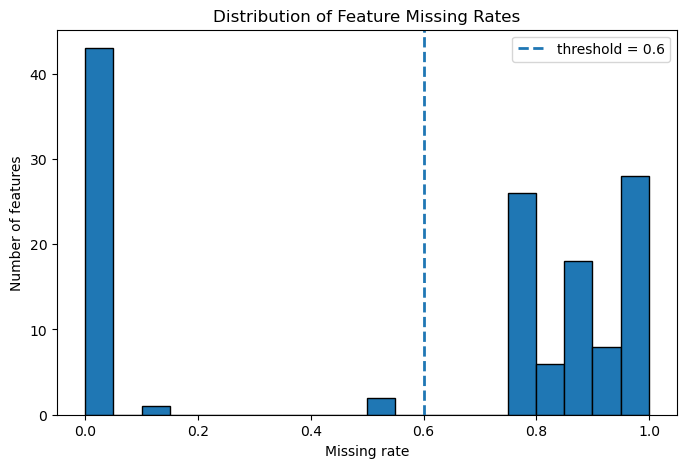

In [25]:
# # Display threshold selection for missing value filtering using a histogram.
# rates = miss["missing_rate"]

# threshold = 0.6

# plt.figure(figsize=(8, 5))
# plt.hist(rates, bins=20, edgecolor="black")
# plt.axvline(threshold, linestyle="--", linewidth=2, label=f"threshold = {threshold}")

# plt.xlabel("Missing rate")
# plt.ylabel("Number of features")
# plt.title("Distribution of Feature Missing Rates")
# plt.legend()
# plt.show()

Total features: 132
Deleted features (missing_rate > 0.6): 86
Kept features: 46
Retention rate: 34.8%

Deleted features:


,feature,missing_rate
0,thrombin_min,0.999480
1,thrombin_max,0.999480
2,ggt_max,0.998394
3,ggt_min,0.998394
4,globulin_max,0.997506
5,globulin_min,0.997506
6,d_dimer_max,0.996803
7,d_dimer_min,0.996803
9,total_protein_max,0.994768
8,total_protein_min,0.994768


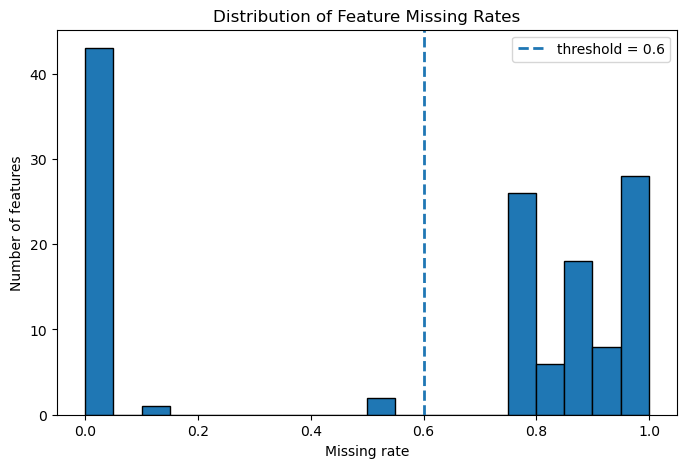

In [10]:
# the merged code of feature filtering using missingness rate
import matplotlib.pyplot as plt
miss = summarize_missingness(df_drop)  

threshold = 0.6

# distinguish those features to be deleted and those retained
deleted_features = miss.loc[miss["missing_rate"] > threshold, "feature"].tolist()
kept_features = miss.loc[miss["missing_rate"] <= threshold, "feature"].tolist()

n_total = len(miss)
n_deleted = len(deleted_features)
n_kept = len(kept_features)

# summarize how many features are deleted and the propotion
print(f"Total features: {n_total}")
print(f"Deleted features (missing_rate > {threshold}): {n_deleted}")
print(f"Kept features: {n_kept}")
print(f"Retention rate: {n_kept / n_total:.1%}")

# listed all the features deleted
deleted_df = miss.loc[miss["missing_rate"] > threshold, ["feature", "missing_rate"]].copy()
deleted_df = deleted_df.sort_values("missing_rate", ascending=False)

print("\nDeleted features:")
pd.set_option("display.max_rows", None)
display(deleted_df)
pd.reset_option("display.max_rows")

# Plot the missing rate histogram and mark the threshold for report writing.
rates = miss["missing_rate"]

plt.figure(figsize=(8, 5))
plt.hist(rates, bins=20, edgecolor="black")
plt.axvline(threshold, linestyle="--", linewidth=2, label=f"threshold = {threshold}")

plt.xlabel("Missing rate")
plt.ylabel("Number of features")
plt.title("Distribution of Feature Missing Rates")
plt.legend()
plt.show()

In [14]:
kept_features

['po2_min',
 'po2_max',
 'marital_status',
 'temperature_max',
 'temperature_min',
 'temperature_mean',
 'glucose_mean',
 'glucose_max',
 'glucose_min',
 'insurance',
 'gcs_motor',
 'gcs_verbal',
 'gcs_eyes',
 'gcs_min',
 'gcs_unable',
 'language',
 'resp_rate_mean',
 'resp_rate_max',
 'resp_rate_min',
 'spo2_min',
 'spo2_mean',
 'spo2_max',
 'mbp_max',
 'mbp_mean',
 'mbp_min',
 'dbp_mean',
 'sbp_min',
 'dbp_max',
 'sbp_max',
 'sbp_mean',
 'dbp_min',
 'heart_rate_mean',
 'heart_rate_max',
 'heart_rate_min',
 'los',
 'sofa2_renal_24h_max',
 'sofa2_liver_24h_max',
 'sofa2_coagulation_24h_max',
 'sofa2_cardiovascular_24h_max',
 'sofa2_respiration_24h_max',
 'sofa2_cns_24h_max',
 'last_careunit',
 'race',
 'age',
 'gender',
 'first_careunit']

In [11]:
# after missing rate filtering, remaining 46 features

X = drop_cols(df_drop, deleted_features).copy()
X

,first_careunit,last_careunit,los,insurance,language,race,marital_status,age,gender,sofa2_respiration_24h_max,...,glucose_min,glucose_max,glucose_mean,gcs_min,gcs_motor,gcs_verbal,gcs_eyes,gcs_unable,po2_min,po2_max
0,PACU,PACU,0.450463,Medicaid,English,WHITE,MARRIED,78,M,0.0,...,148.0,148.0,148.000000,15.0,6.0,5.0,4.0,0.0,NaN,NaN
1,PACU,PACU,5.047350,Medicare,English,WHITE,DIVORCED,91,F,0.0,...,121.0,212.0,158.916667,10.0,4.0,4.0,2.0,0.0,NaN,NaN
2,PACU,PACU,1.088669,Medicare,English,UNABLE TO OBTAIN,MARRIED,86,M,0.0,...,134.0,135.0,134.500000,9.0,6.0,1.0,2.0,0.0,NaN,NaN
3,PACU,PACU,0.991192,Medicare,English,WHITE - OTHER EUROPEAN,MARRIED,86,M,0.0,...,133.0,147.0,140.000000,15.0,1.0,0.0,1.0,1.0,NaN,NaN
4,PACU,PACU,0.934479,Medicare,English,WHITE - BRAZILIAN,SINGLE,77,F,0.0,...,123.0,123.0,123.000000,14.0,6.0,5.0,3.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65361,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),0.659537,Private,English,WHITE,MARRIED,54,F,0.0,...,113.0,113.0,113.000000,15.0,6.0,5.0,4.0,0.0,NaN,NaN
65362,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),1.402049,Medicare,English,WHITE,SINGLE,60,M,0.0,...,177.0,302.0,229.333333,14.0,6.0,5.0,3.0,0.0,NaN,NaN
65363,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),1.888623,Medicare,English,BLACK/AFRICAN AMERICAN,DIVORCED,51,M,0.0,...,89.0,122.0,108.800000,15.0,6.0,5.0,4.0,0.0,NaN,NaN
65364,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),6.765324,Medicare,English,WHITE,DIVORCED,63,M,0.0,...,108.0,108.0,108.000000,7.0,5.0,1.0,1.0,0.0,148.0,148.0


In [12]:
import numpy as np

n = len(X)
rows = []

for c in X.columns:
    s = X[c]
    dtype = str(s.dtype)

    if pd.api.types.is_numeric_dtype(s):
        v = float(np.nanvar(s.to_numpy(dtype=float)))
        rows.append({
            "feature": c,
            "dtype": dtype,
            "numeric_variance": v,
            "dominant_rate": np.nan,
            "low_variance_score": v,  # numeric：直接用 variance
        })
    else:
        # categorical：看“最常见值比例”（越高越接近“低变化/低方差”）
        vc = s.astype("object").value_counts(dropna=False)
        dom_rate = float(vc.iloc[0] / n) if len(vc) > 0 else np.nan
        rows.append({
            "feature": c,
            "dtype": dtype,
            "numeric_variance": np.nan,
            "dominant_rate": dom_rate,
            "low_variance_score": dom_rate,  # categorical：用 dominant_rate（越高越“低变化”）
        })

lv = pd.DataFrame(rows)

# 排序方式：
# - numeric：variance 从小到大（越小越低方差）
# - categorical：dominant_rate 从大到小（越大越低变化）
lv_num = lv[lv["numeric_variance"].notna()].sort_values("numeric_variance", ascending=True)
lv_cat = lv[lv["dominant_rate"].notna()].sort_values("dominant_rate", ascending=False)

print("Numeric features (lowest variance first):")
display(lv_num.head(30))

print("Categorical features (highest dominant_rate first):")
display(lv_cat.head(30))

# 保存全表
lv_path = OUTPUT_DIR / "low_variance_ranking_all_features.csv"
lv.to_csv(lv_path, index=False)
# print("Saved:", lv_path)
print("Successfully Saved:")


Numeric features (lowest variance first):


,feature,dtype,numeric_variance,dominant_rate,low_variance_score
43,gcs_unable,float64,0.165264,NaN,0.165264
32,temperature_mean,float64,0.275118,NaN,0.275118
12,sofa2_liver_24h_max,float64,0.286961,NaN,0.286961
9,sofa2_respiration_24h_max,float64,0.331791,NaN,0.331791
14,sofa2_cns_24h_max,float64,0.457882,NaN,0.457882
13,sofa2_renal_24h_max,float64,0.484319,NaN,0.484319
31,temperature_max,float64,0.500537,NaN,0.500537
30,temperature_min,float64,0.505033,NaN,0.505033
11,sofa2_coagulation_24h_max,float64,0.646123,NaN,0.646123
10,sofa2_cardiovascular_24h_max,float64,0.928646,NaN,0.928646


Categorical features (highest dominant_rate first):


,feature,dtype,numeric_variance,dominant_rate,low_variance_score
4,language,object,NaN,0.903773,0.903773
5,race,object,NaN,0.617951,0.617951
8,gender,object,NaN,0.561760,0.561760
3,insurance,object,NaN,0.527247,0.527247
6,marital_status,object,NaN,0.447465,0.447465
0,first_careunit,object,NaN,0.189793,0.189793
1,last_careunit,object,NaN,0.189793,0.189793


Successfully Saved:


In [13]:
df_raw = df.copy()  # <- 如果你原始数据就是 df

y_col = "icu_death_flag"   # 或你的真实标签列
# assert y_col in df_raw.columns, f"{y_col} not in df_raw.columns"

# since the feature have been deleted before, so we need to copy the label and add it to the current df
df_model = X.copy()

df_model[y_col] = pd.to_numeric(df_raw.loc[df_model.index, y_col], errors="coerce").fillna(0).astype(int).clip(0, 1)


In [14]:
df.shape

(65366, 140)

In [15]:
df_model.shape

(65366, 47)

In [16]:
 
#split train, test, validation set

# The name of the label column
# y_col = "icu_death_flag" 

# print("df_model:", df_model.shape)
# assert y_col in df_model.columns, f"{y_col} not in df_model.columns"

# the previous defined stratified_split
train_df, test_df = stratified_split(df_model, y_col=y_col, test_size=CFG.test_size, seed=CFG.random_seed)

print("train:", train_df.shape, "test:", test_df.shape)
train_df.head()

train: (52292, 47) test: (13074, 47)


,first_careunit,last_careunit,los,insurance,language,race,marital_status,age,gender,sofa2_respiration_24h_max,...,glucose_max,glucose_mean,gcs_min,gcs_motor,gcs_verbal,gcs_eyes,gcs_unable,po2_min,po2_max,icu_death_flag
37363,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),6.624271,Medicare,English,WHITE,DIVORCED,78,F,1.0,...,147.0,124.000000,6.0,4.0,1.0,1.0,0.0,153.0,292.0,1
30961,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2.694201,Medicare,English,WHITE,MARRIED,78,F,0.0,...,246.0,168.285714,15.0,1.0,0.0,1.0,1.0,NaN,NaN,0
27971,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),1.546146,Medicare,English,WHITE,WIDOWED,86,F,0.0,...,176.0,139.142857,8.0,5.0,1.0,2.0,0.0,33.0,72.0,0
23405,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),1.096343,Medicare,English,WHITE,MARRIED,58,F,0.0,...,136.0,125.000000,15.0,6.0,5.0,4.0,0.0,NaN,NaN,0
56943,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),1.493229,Private,English,WHITE,SINGLE,40,M,0.0,...,118.0,114.500000,15.0,6.0,5.0,4.0,0.0,NaN,NaN,0


In [50]:
# # imputation
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer


# X_train_raw = train_df.drop(columns=[y_col], errors="ignore")
# X_test_raw  = test_df.drop(columns=[y_col], errors="ignore")

# # Convert all values in column y to numeric.
# y_train = train_df[y_col].to_numpy().astype(int)
# y_test  = test_df[y_col].to_numpy().astype(int)

# num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
# cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# # For columns with num type data, fill missing values with the median; for categorical data columns, fill missing values with the most frequent value.
# imputer = ColumnTransformer(
#     transformers=[
#         ("num", SimpleImputer(strategy="median"), num_cols),
#         ("cat", SimpleImputer(strategy="most_frequent"), cat_cols),
#     ],
#     remainder="drop",
#     verbose_feature_names_out=False,
# )

# # only the training data are used to make the imputer
# imputer.fit(X_train_raw)

# # apply the imputer to the train and test data
# X_train_imp = pd.DataFrame(imputer.transform(X_train_raw), columns=num_cols + cat_cols, index=X_train_raw.index)
# X_test_imp  = pd.DataFrame(imputer.transform(X_test_raw),  columns=num_cols + cat_cols, index=X_test_raw.index)


# print("Train max missing AFTER:", float(X_train_imp.isna().mean().max()))
# print("Test  max missing AFTER:", float(X_test_imp.isna().mean().max()))

In [28]:
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, auc, roc_curve
)


BASELINE_DIR = CFG.outputs_dir / "baseline"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
CFG.tables_dir.mkdir(parents=True, exist_ok=True)

y_col = CFG.target_col
seed = CFG.random_seed

def infer_num_cat_cols(df: pd.DataFrame, y_col: str):
    """
    distinguish numerical and categorical data columns
    """
    X = df.drop(columns=[y_col], errors="ignore")
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    return num_cols, cat_cols


def collapse_selected_categories(df: pd.DataFrame) -> pd.DataFrame:
    """
    since the race column there are many feature values that can be combined, such as "ASIAN - CHINESE" → "ASIAN" "ASIAN - KOREAN" → "ASIAN"
    so we take the content before - as the eigenvalue, thereby reducing the sparsity of the feature matrix after one-hot encoding.
    """
    df = df.copy()

    if "race" in df.columns:
        df["race"] = df["race"].astype("object").apply(
            lambda x: x.split("-")[0].strip() if isinstance(x, str) and "-" in x else x
        )

    return df

def make_preprocessor(num_cols, cat_cols):
    """
    impute the missing data, dependent on numerical and categorical data
    """
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),   # Only standardize numeric.
    ])
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def stratified_subsplit(y: np.ndarray, val_size: float, seed: int):
    """
    split the raw train set into train and validation set, the validation is used for threshhold selection
    """
    idx = np.arange(len(y))
    sub_idx, val_idx = train_test_split(
        idx, test_size=val_size, random_state=seed, stratify=y
    )
    return sub_idx, val_idx

def choose_threshold_by_f1_prcurve(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """
    using the f1 performance to select the threshold
    """
    precision, recall, thr = precision_recall_curve(y_true, y_prob)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_i = int(np.nanargmax(f1))
    return float(thr[best_i])

    
def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, thr: float) -> dict:
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auroc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else float("nan"),
        "ap": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else float("nan"),
        "threshold": float(thr),
    }

# def save_artifacts(model_name: str, pipe, y_test: np.ndarray, y_test_prob: np.ndarray, thr: float, metrics: dict):
#     out = BASELINE_DIR / model_name
#     out.mkdir(parents=True, exist_ok=True)

#     joblib.dump(pipe, out / f"{model_name}.joblib")

#     pred_df = pd.DataFrame({
#         "y_true": y_test.astype(int),
#         "y_prob": y_test_prob.astype(float),
#         "y_pred": (y_test_prob >= thr).astype(int),
#     })
#     pred_df.to_csv(out / f"{model_name}_test_predictions.csv", index=False)

#     with open(out / f"{model_name}_metrics.json", "w") as f:
#         json.dump(metrics, f, indent=2)

#     cm = confusion_matrix(y_test, (y_test_prob >= thr).astype(int))
#     ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", colorbar=True)
#     plt.title(f"{model_name} | thr={thr:.3f}")
#     plt.tight_layout()
#     plt.savefig(out / f"{model_name}_confusion_matrix.png", dpi=200)
#     plt.show()

#     # precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
#     # plt.figure()
#     # plt.plot(recall, precision)
#     # plt.xlabel("Recall")
#     # plt.ylabel("Precision")
#     # plt.title(f"PR Curve: {model_name}")
#     # plt.tight_layout()
#     # plt.savefig(out / f"{model_name}_pr_curve.png", dpi=200)
#     # plt.show()
#     precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
#     plt.figure()
#     plt.plot(recall, precision, label=f"AP = {metrics['ap']:.3f}")
#     plt.xlabel("Recall")
#     plt.ylabel("Precision")
#     plt.title(f"PR Curve: {model_name}")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(out / f"{model_name}_pr_curve.png", dpi=200)
#     plt.show()


#     fpr, tpr, _ = roc_curve(y_test, y_test_prob)
#     roc_auc = auc(fpr, tpr)
    
#     plt.figure()
#     plt.plot(fpr, tpr, label=f"AUROC = {roc_auc:.3f}")
#     plt.plot([0, 1], [0, 1], linestyle="--")
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.title(f"ROC Curve: {model_name}")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(out / f"{model_name}_roc_curve.png", dpi=200)
#     plt.show()

#     # print("Saved to:", out)
#     print("Finished Saving")


def save_artifacts(
    model_name: str,
    model,
    y_test: np.ndarray,
    y_test_prob: np.ndarray,
    thr: float,
    metrics: dict,
    parent_dir: Path | None = None,
):
    if parent_dir is None:
        parent_dir = BASELINE_DIR

    out = parent_dir / model_name
    out.mkdir(parents=True, exist_ok=True)

    joblib.dump(model, out / f"{model_name}.joblib")

    pred_df = pd.DataFrame({
        "y_true": y_test.astype(int),
        "y_prob": y_test_prob.astype(float),
        "y_pred": (y_test_prob >= thr).astype(int),
    })
    pred_df.to_csv(out / f"{model_name}_test_predictions.csv", index=False)

    with open(out / f"{model_name}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    cm = confusion_matrix(y_test, (y_test_prob >= thr).astype(int))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", colorbar=True)
    plt.title(f"{model_name} | thr={thr:.3f}")
    plt.tight_layout()
    plt.savefig(out / f"{model_name}_confusion_matrix.png", dpi=200)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
    plt.figure()
    plt.plot(recall, precision, label=f"AP = {metrics['ap']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve: {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out / f"{model_name}_pr_curve.png", dpi=200)
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUROC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out / f"{model_name}_roc_curve.png", dpi=200)
    plt.show()

    # print("Finished Saving to:", out)
    print("Finished Saving")
    

print("Preprocessor + utils ready")

Preprocessor + utils ready


In [30]:
# from sklearn.linear_model import LogisticRegression

# MODEL_NAME = "logreg"
# assert MODEL_NAME in CFG.run_models

# # for trainset and test data, separate the training features (X_train_raw) and the label
# # since the following preprocessing can only be done for the feature sets instead of the label
# X_train_raw = train_df.drop(columns=[y_col], errors="ignore")
# X_test_raw  = test_df.drop(columns=[y_col], errors="ignore")


# # since the "race" feature have many feature values that has the same Prefix, We merge the eigenvalues to reduce the sparsity of the feature matrix in the subsequent one-hot encoding.
# X_train_raw = collapse_selected_categories(train_df.drop(columns=[y_col], errors="ignore"))
# X_test_raw  = collapse_selected_categories(test_df.drop(columns=[y_col], errors="ignore"))

    
# y_train = train_df[y_col].to_numpy().astype(int)
# y_test  = test_df[y_col].to_numpy().astype(int)

# # define the preprocessor for imputing and scaling
# num_cols, cat_cols = infer_num_cat_cols(train_df, y_col=y_col)
# preprocessor = make_preprocessor(num_cols, cat_cols)

# sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
# X_sub, y_sub = X_train_raw.iloc[sub_idx], y_train[sub_idx]
# X_val, y_val = X_train_raw.iloc[val_idx], y_train[val_idx]

# # define the pipeline for processing and using the lrg model
# pipe = Pipeline(steps=[
#     ("prep", preprocessor),
#     ("clf", LogisticRegression(
#         penalty="l2", C=1.0, class_weight="balanced",
#         max_iter=2000, solver="lbfgs", random_state=seed
#     ))
# ])

# pipe.fit(X_sub, y_sub)
# y_val_prob = pipe.predict_proba(X_val)[:, 1]
# thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)

# pipe_final = clone(pipe)
# pipe_final.fit(X_train_raw, y_train)
# y_test_prob = pipe_final.predict_proba(X_test_raw)[:, 1]

# mets = compute_metrics(y_test, y_test_prob, thr)
# print(MODEL_NAME, mets)
# save_artifacts(MODEL_NAME, pipe_final, y_test, y_test_prob, thr, mets)

Raw feature count before one-hot encoding: 46
Feature count after preprocessing / one-hot encoding: 122
Preprocessor fitting time: 0.298 seconds
Transformed feature names:
['los' 'age' 'sofa2_respiration_24h_max' 'sofa2_cardiovascular_24h_max'
 'sofa2_coagulation_24h_max' 'sofa2_liver_24h_max' 'sofa2_renal_24h_max'
 'sofa2_cns_24h_max' 'heart_rate_min' 'heart_rate_max' 'heart_rate_mean'
 'sbp_min' 'sbp_max' 'sbp_mean' 'dbp_min' 'dbp_max' 'dbp_mean' 'mbp_min'
 'mbp_max' 'mbp_mean' 'resp_rate_min' 'resp_rate_max' 'resp_rate_mean'
 'temperature_min' 'temperature_max' 'temperature_mean' 'spo2_min'
 'spo2_max' 'spo2_mean' 'glucose_min' 'glucose_max' 'glucose_mean'
 'gcs_min' 'gcs_motor' 'gcs_verbal' 'gcs_eyes' 'gcs_unable' 'po2_min'
 'po2_max' 'first_careunit_Cardiac Vascular Intensive Care Unit (CVICU)'
 'first_careunit_Coronary Care Unit (CCU)'
 'first_careunit_Intensive Care Unit (ICU)' 'first_careunit_Med/Surg'
 'first_careunit_Medical Intensive Care Unit (MICU)'
 'first_careunit_Medica

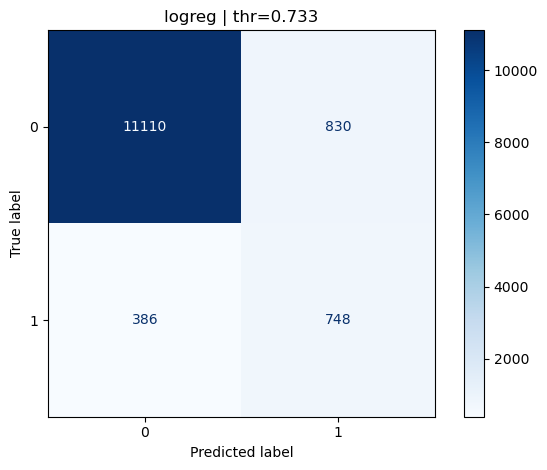

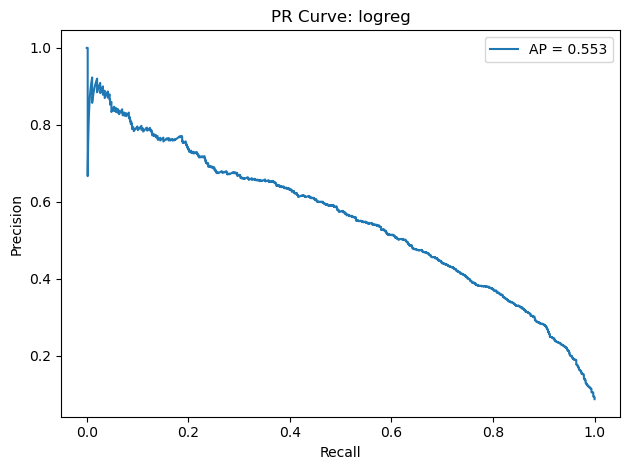

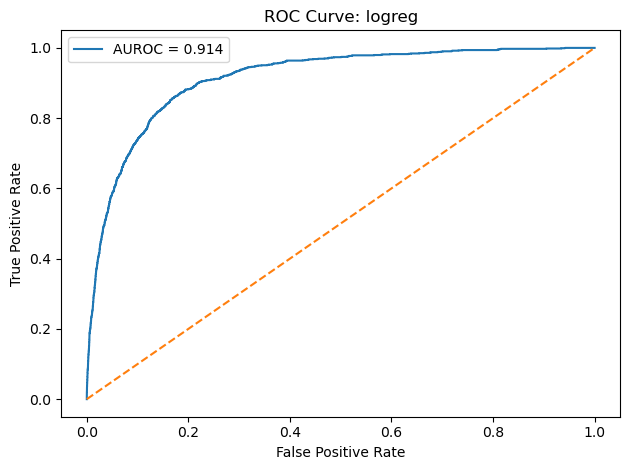

Finished Saving
Artifact saving time: 0.598 seconds
Done.


In [32]:
import time
from sklearn.linear_model import LogisticRegression

MODEL_NAME = "logreg"
assert MODEL_NAME in CFG.run_models


# Prepare raw features, in the step, also redefine the feature values in race columns
X_train_raw = collapse_selected_categories(
    train_df.drop(columns=[y_col], errors="ignore")
).copy()

X_test_raw = collapse_selected_categories(
    test_df.drop(columns=[y_col], errors="ignore")
).copy()

y_train = train_df[y_col].to_numpy().astype(int)
y_test  = test_df[y_col].to_numpy().astype(int)


# Infer numeric / categorical columns Use the processed X_train_raw instead of train_df

num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# define the preprocessor
preprocessor = make_preprocessor(num_cols, cat_cols)

# split train and val from the current trainset, this validation set is used for threshold selection
sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_raw.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_raw.iloc[val_idx], y_train[val_idx]

# build pipeline
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced", # using the balanced keyword for imblanced scenarios
        max_iter=2000,
        solver="lbfgs",
        random_state=seed
    ))
])

# print the existing feature counts (after the one-hot processing for categorical data)
n_raw_features = X_train_raw.shape[1]
print(f"Raw feature count before one-hot encoding: {n_raw_features}")

# Fit preprocessor alone once to inspect expanded feature count
prep_start = time.perf_counter()
preprocessor.fit(X_sub)
prep_end = time.perf_counter()

feature_names_after_prep = preprocessor.get_feature_names_out()
n_features_after_prep = len(feature_names_after_prep)

print(f"Feature count after preprocessing / one-hot encoding: {n_features_after_prep}")
print(f"Preprocessor fitting time: {prep_end - prep_start:.3f} seconds")

# Optional: print first few feature names
# print("First 20 transformed feature names:")
# print(feature_names_after_prep[:20])
print("Transformed feature names:")
print(feature_names_after_prep)


# Train on sub-train (60% of all the data, since 20% validation, and 20% for test) and choose threshold
train_start = time.perf_counter()
pipe.fit(X_sub, y_sub)
train_end = time.perf_counter()

print(f"Sub-train fitting time: {train_end - train_start:.3f} seconds")

val_pred_start = time.perf_counter()
y_val_prob = pipe.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()

print(f"Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"Selected threshold from validation set: {thr:.4f}")


# Refit on full training set (80% of the whole data)

pipe_final = clone(pipe)

final_train_start = time.perf_counter()
pipe_final.fit(X_train_raw, y_train)
final_train_end = time.perf_counter()

print(f"Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")


# Test 
test_pred_start = time.perf_counter()
y_test_prob = pipe_final.predict_proba(X_test_raw)[:, 1]
test_pred_end = time.perf_counter()

print(f"Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")


# Metrics + save artifacts

mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, pipe_final, y_test, y_test_prob, thr, mets)
save_end = time.perf_counter()

print(f"Artifact saving time: {save_end - save_start:.3f} seconds")
print("Done.")

[rf] Raw feature count before one-hot encoding: 46
[rf] Feature count after preprocessing / one-hot encoding: 122
[rf] Preprocessor fitting time: 0.221 seconds
[rf] Transformed feature names:
['los' 'age' 'sofa2_respiration_24h_max' 'sofa2_cardiovascular_24h_max'
 'sofa2_coagulation_24h_max' 'sofa2_liver_24h_max' 'sofa2_renal_24h_max'
 'sofa2_cns_24h_max' 'heart_rate_min' 'heart_rate_max' 'heart_rate_mean'
 'sbp_min' 'sbp_max' 'sbp_mean' 'dbp_min' 'dbp_max' 'dbp_mean' 'mbp_min'
 'mbp_max' 'mbp_mean' 'resp_rate_min' 'resp_rate_max' 'resp_rate_mean'
 'temperature_min' 'temperature_max' 'temperature_mean' 'spo2_min'
 'spo2_max' 'spo2_mean' 'glucose_min' 'glucose_max' 'glucose_mean'
 'gcs_min' 'gcs_motor' 'gcs_verbal' 'gcs_eyes' 'gcs_unable' 'po2_min'
 'po2_max' 'first_careunit_Cardiac Vascular Intensive Care Unit (CVICU)'
 'first_careunit_Coronary Care Unit (CCU)'
 'first_careunit_Intensive Care Unit (ICU)' 'first_careunit_Med/Surg'
 'first_careunit_Medical Intensive Care Unit (MICU)'
 'f

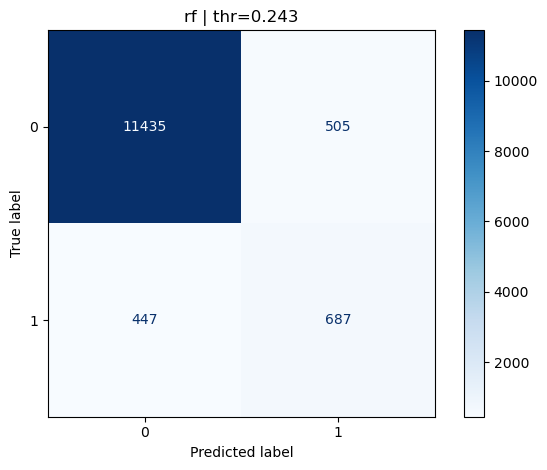

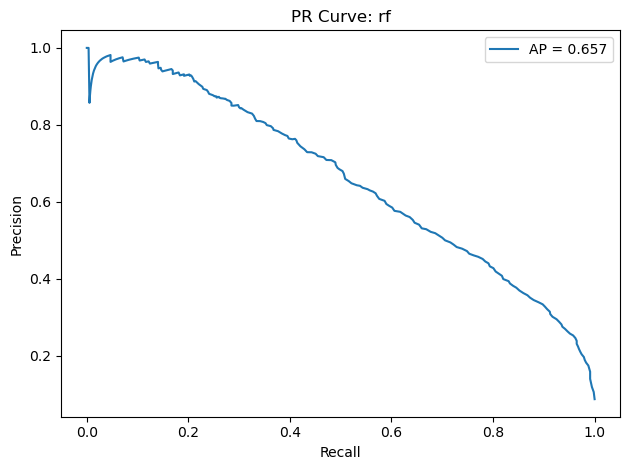

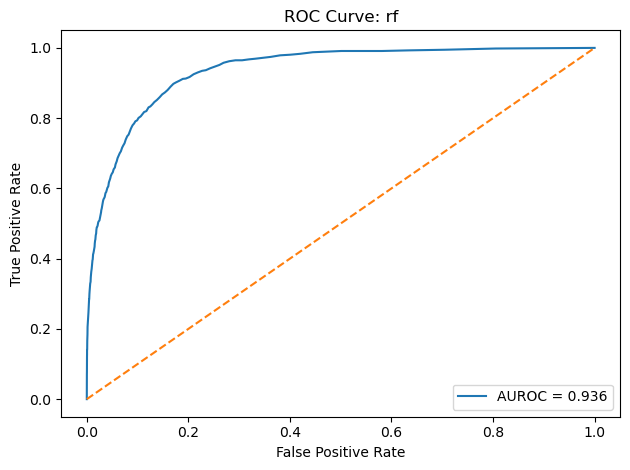

Finished Saving
[rf] Artifact saving time: 0.705 seconds
[rf] Done.


In [33]:
import time
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

MODEL_NAME = "rf"
assert MODEL_NAME in CFG.run_models

# Prepare raw features
X_train_raw = collapse_selected_categories(
    train_df.drop(columns=[y_col], errors="ignore")
).copy()

X_test_raw = collapse_selected_categories(
    test_df.drop(columns=[y_col], errors="ignore")
).copy()

y_train = train_df[y_col].to_numpy().astype(int)
y_test  = test_df[y_col].to_numpy().astype(int)

# Infer numeric / categorical columns
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# Define preprocessor
preprocessor = make_preprocessor(num_cols, cat_cols)

# Train / validation split for threshold selection
sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_raw.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_raw.iloc[val_idx], y_train[val_idx]

# Build pipeline
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    ))
])

# Feature counts
n_raw_features = X_train_raw.shape[1]
print(f"[{MODEL_NAME}] Raw feature count before one-hot encoding: {n_raw_features}")

prep_start = time.perf_counter()
preprocessor.fit(X_sub)
prep_end = time.perf_counter()

feature_names_after_prep = preprocessor.get_feature_names_out()
n_features_after_prep = len(feature_names_after_prep)

print(f"[{MODEL_NAME}] Feature count after preprocessing / one-hot encoding: {n_features_after_prep}")
print(f"[{MODEL_NAME}] Preprocessor fitting time: {prep_end - prep_start:.3f} seconds")
print(f"[{MODEL_NAME}] Transformed feature names:")
print(feature_names_after_prep)

# Train on sub-train
train_start = time.perf_counter()
pipe.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

# Validation prediction
val_pred_start = time.perf_counter()
y_val_prob = pipe.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

# Refit on full training set
pipe_final = clone(pipe)

final_train_start = time.perf_counter()
pipe_final.fit(X_train_raw, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

# Test prediction
test_pred_start = time.perf_counter()
y_test_prob = pipe_final.predict_proba(X_test_raw)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

# Metrics + save artifacts
mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, pipe_final, y_test, y_test_prob, thr, mets)
save_end = time.perf_counter()
print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

[gb] Raw feature count before one-hot encoding: 46
[gb] Feature count after preprocessing / one-hot encoding: 122
[gb] Preprocessor fitting time: 0.223 seconds
[gb] Transformed feature names:
['los' 'age' 'sofa2_respiration_24h_max' 'sofa2_cardiovascular_24h_max'
 'sofa2_coagulation_24h_max' 'sofa2_liver_24h_max' 'sofa2_renal_24h_max'
 'sofa2_cns_24h_max' 'heart_rate_min' 'heart_rate_max' 'heart_rate_mean'
 'sbp_min' 'sbp_max' 'sbp_mean' 'dbp_min' 'dbp_max' 'dbp_mean' 'mbp_min'
 'mbp_max' 'mbp_mean' 'resp_rate_min' 'resp_rate_max' 'resp_rate_mean'
 'temperature_min' 'temperature_max' 'temperature_mean' 'spo2_min'
 'spo2_max' 'spo2_mean' 'glucose_min' 'glucose_max' 'glucose_mean'
 'gcs_min' 'gcs_motor' 'gcs_verbal' 'gcs_eyes' 'gcs_unable' 'po2_min'
 'po2_max' 'first_careunit_Cardiac Vascular Intensive Care Unit (CVICU)'
 'first_careunit_Coronary Care Unit (CCU)'
 'first_careunit_Intensive Care Unit (ICU)' 'first_careunit_Med/Surg'
 'first_careunit_Medical Intensive Care Unit (MICU)'
 'f

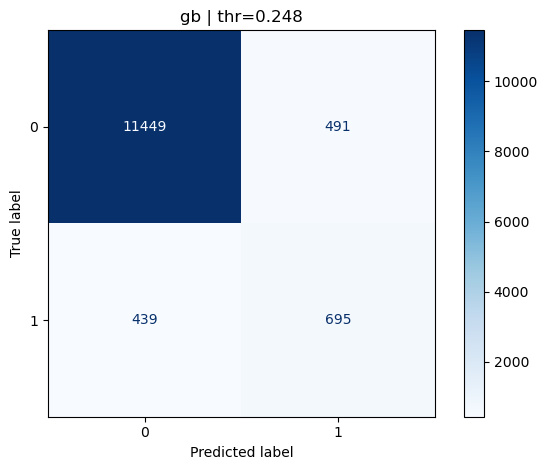

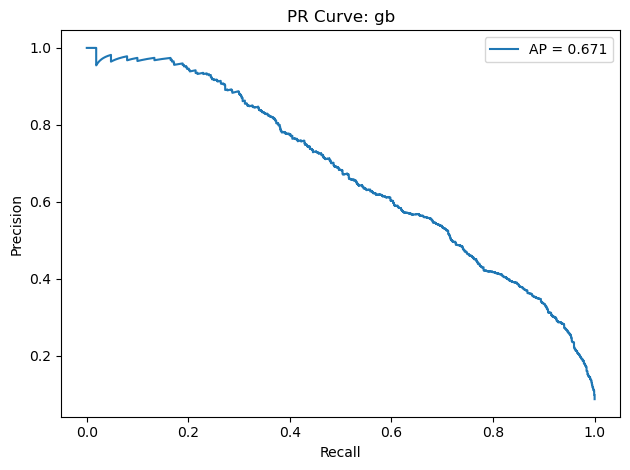

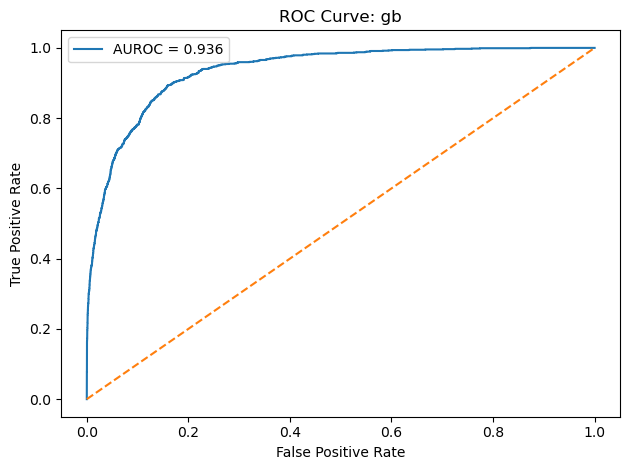

Finished Saving
[gb] Artifact saving time: 0.554 seconds
[gb] Done.


In [34]:
import time
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

MODEL_NAME = "gb"
assert MODEL_NAME in CFG.run_models

# Prepare raw features
X_train_raw = collapse_selected_categories(
    train_df.drop(columns=[y_col], errors="ignore")
).copy()

X_test_raw = collapse_selected_categories(
    test_df.drop(columns=[y_col], errors="ignore")
).copy()

y_train = train_df[y_col].to_numpy().astype(int)
y_test  = test_df[y_col].to_numpy().astype(int)

# Infer numeric / categorical columns
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# Define preprocessor
preprocessor = make_preprocessor(num_cols, cat_cols)

# Train / validation split for threshold selection
sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_raw.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_raw.iloc[val_idx], y_train[val_idx]

# Build pipeline
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=seed
    ))
])

# Feature counts
n_raw_features = X_train_raw.shape[1]
print(f"[{MODEL_NAME}] Raw feature count before one-hot encoding: {n_raw_features}")

prep_start = time.perf_counter()
preprocessor.fit(X_sub)
prep_end = time.perf_counter()

feature_names_after_prep = preprocessor.get_feature_names_out()
n_features_after_prep = len(feature_names_after_prep)

print(f"[{MODEL_NAME}] Feature count after preprocessing / one-hot encoding: {n_features_after_prep}")
print(f"[{MODEL_NAME}] Preprocessor fitting time: {prep_end - prep_start:.3f} seconds")
print(f"[{MODEL_NAME}] Transformed feature names:")
print(feature_names_after_prep)

# Train on sub-train
train_start = time.perf_counter()
pipe.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

# Validation prediction
val_pred_start = time.perf_counter()
y_val_prob = pipe.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

# Refit on full training set
pipe_final = clone(pipe)

final_train_start = time.perf_counter()
pipe_final.fit(X_train_raw, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

# Test prediction
test_pred_start = time.perf_counter()
y_test_prob = pipe_final.predict_proba(X_test_raw)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

# Metrics + save artifacts
mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, pipe_final, y_test, y_test_prob, thr, mets)
save_end = time.perf_counter()
print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

[xgb] Raw feature count before one-hot encoding: 46
[xgb] Feature count after preprocessing / one-hot encoding: 122
[xgb] Preprocessor fitting time: 0.224 seconds
[xgb] Transformed feature names:
['los' 'age' 'sofa2_respiration_24h_max' 'sofa2_cardiovascular_24h_max'
 'sofa2_coagulation_24h_max' 'sofa2_liver_24h_max' 'sofa2_renal_24h_max'
 'sofa2_cns_24h_max' 'heart_rate_min' 'heart_rate_max' 'heart_rate_mean'
 'sbp_min' 'sbp_max' 'sbp_mean' 'dbp_min' 'dbp_max' 'dbp_mean' 'mbp_min'
 'mbp_max' 'mbp_mean' 'resp_rate_min' 'resp_rate_max' 'resp_rate_mean'
 'temperature_min' 'temperature_max' 'temperature_mean' 'spo2_min'
 'spo2_max' 'spo2_mean' 'glucose_min' 'glucose_max' 'glucose_mean'
 'gcs_min' 'gcs_motor' 'gcs_verbal' 'gcs_eyes' 'gcs_unable' 'po2_min'
 'po2_max' 'first_careunit_Cardiac Vascular Intensive Care Unit (CVICU)'
 'first_careunit_Coronary Care Unit (CCU)'
 'first_careunit_Intensive Care Unit (ICU)' 'first_careunit_Med/Surg'
 'first_careunit_Medical Intensive Care Unit (MICU)'

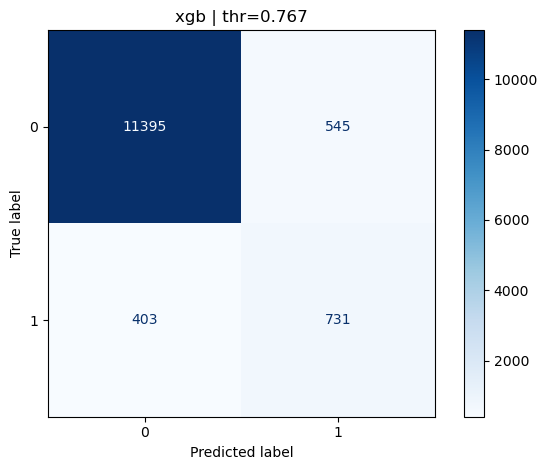

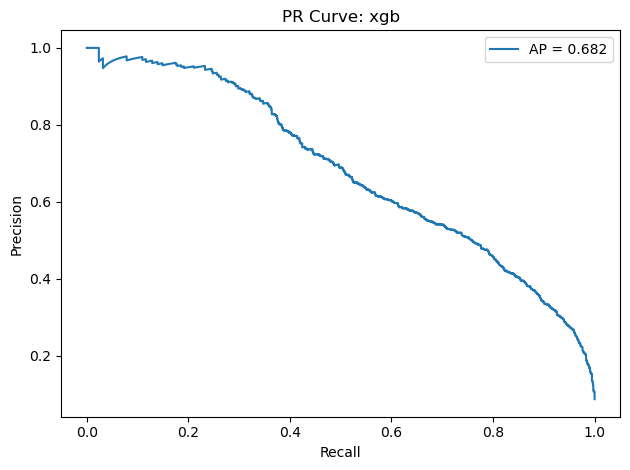

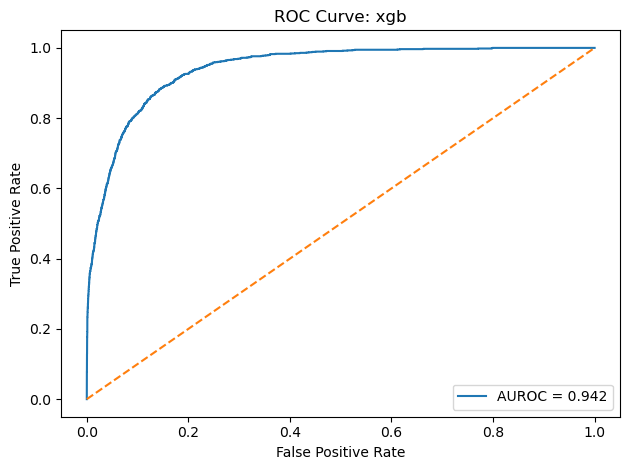

Finished Saving
[xgb] Artifact saving time: 0.553 seconds
[xgb] Done.


In [36]:
import time
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

MODEL_NAME = "xgb"
assert MODEL_NAME in CFG.run_models

# Prepare raw features
X_train_raw = collapse_selected_categories(
    train_df.drop(columns=[y_col], errors="ignore")
).copy()

X_test_raw = collapse_selected_categories(
    test_df.drop(columns=[y_col], errors="ignore")
).copy()

y_train = train_df[y_col].to_numpy().astype(int)
y_test  = test_df[y_col].to_numpy().astype(int)

# Infer numeric / categorical columns
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# Define preprocessor
preprocessor = make_preprocessor(num_cols, cat_cols)

# Train / validation split for threshold selection
sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_raw.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_raw.iloc[val_idx], y_train[val_idx]

# Class imbalance ratio for XGBoost
n_neg = int((y_sub == 0).sum())
n_pos = int((y_sub == 1).sum())
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

# Build pipeline
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=seed,
        n_jobs=-1
    ))
])

# Feature counts
n_raw_features = X_train_raw.shape[1]
print(f"[{MODEL_NAME}] Raw feature count before one-hot encoding: {n_raw_features}")

prep_start = time.perf_counter()
preprocessor.fit(X_sub)
prep_end = time.perf_counter()

feature_names_after_prep = preprocessor.get_feature_names_out()
n_features_after_prep = len(feature_names_after_prep)

print(f"[{MODEL_NAME}] Feature count after preprocessing / one-hot encoding: {n_features_after_prep}")
print(f"[{MODEL_NAME}] Preprocessor fitting time: {prep_end - prep_start:.3f} seconds")
print(f"[{MODEL_NAME}] Transformed feature names:")
print(feature_names_after_prep)

# Train on sub-train
train_start = time.perf_counter()
pipe.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

# Validation prediction
val_pred_start = time.perf_counter()
y_val_prob = pipe.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

# Refit on full training set
pipe_final = clone(pipe)

# Recompute imbalance ratio on full training set
n_neg_full = int((y_train == 0).sum())
n_pos_full = int((y_train == 1).sum())
pipe_final.set_params(
    clf__scale_pos_weight=(n_neg_full / n_pos_full if n_pos_full > 0 else 1.0)
)

final_train_start = time.perf_counter()
pipe_final.fit(X_train_raw, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

# Test prediction
test_pred_start = time.perf_counter()
y_test_prob = pipe_final.predict_proba(X_test_raw)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

# Metrics + save artifacts
mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, pipe_final, y_test, y_test_prob, thr, mets)
save_end = time.perf_counter()
print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")



[svm_rbf] Raw feature count before one-hot encoding: 46
[svm_rbf] Feature count after preprocessing / one-hot encoding: 122
[svm_rbf] Preprocessor fitting time: 0.228 seconds
[svm_rbf] Transformed feature names:
['los' 'age' 'sofa2_respiration_24h_max' 'sofa2_cardiovascular_24h_max'
 'sofa2_coagulation_24h_max' 'sofa2_liver_24h_max' 'sofa2_renal_24h_max'
 'sofa2_cns_24h_max' 'heart_rate_min' 'heart_rate_max' 'heart_rate_mean'
 'sbp_min' 'sbp_max' 'sbp_mean' 'dbp_min' 'dbp_max' 'dbp_mean' 'mbp_min'
 'mbp_max' 'mbp_mean' 'resp_rate_min' 'resp_rate_max' 'resp_rate_mean'
 'temperature_min' 'temperature_max' 'temperature_mean' 'spo2_min'
 'spo2_max' 'spo2_mean' 'glucose_min' 'glucose_max' 'glucose_mean'
 'gcs_min' 'gcs_motor' 'gcs_verbal' 'gcs_eyes' 'gcs_unable' 'po2_min'
 'po2_max' 'first_careunit_Cardiac Vascular Intensive Care Unit (CVICU)'
 'first_careunit_Coronary Care Unit (CCU)'
 'first_careunit_Intensive Care Unit (ICU)' 'first_careunit_Med/Surg'
 'first_careunit_Medical Intensive C

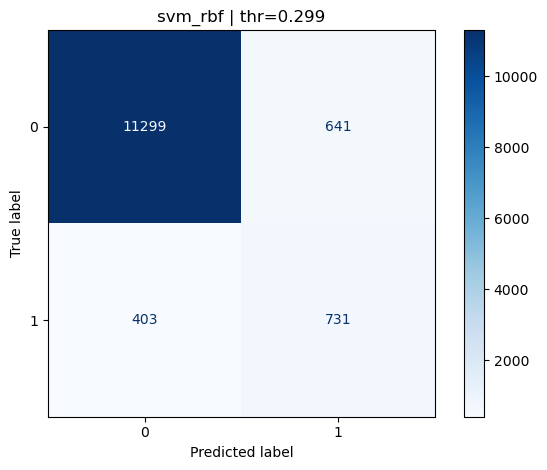

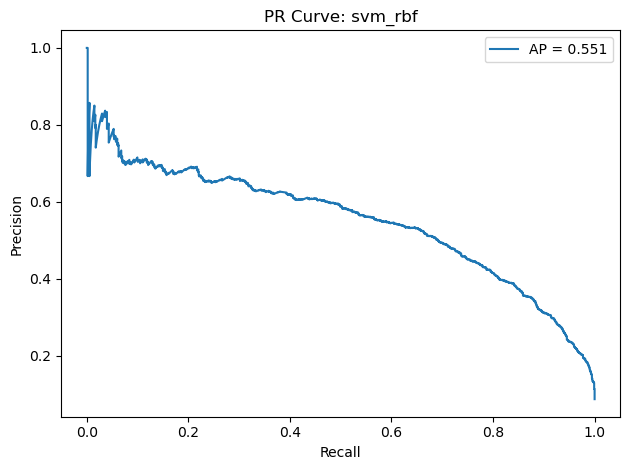

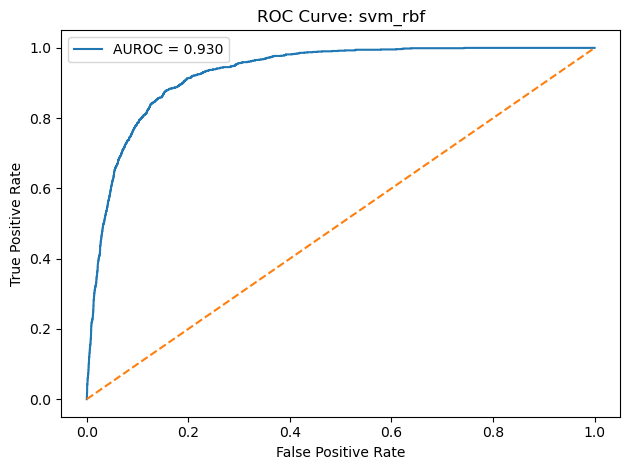

Finished Saving
[svm_rbf] Artifact saving time: 0.461 seconds
[svm_rbf] Done.


In [18]:
import time
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

MODEL_NAME = "svm_rbf"
assert MODEL_NAME in CFG.run_models

# Prepare raw features
X_train_raw = collapse_selected_categories(
    train_df.drop(columns=[y_col], errors="ignore")
).copy()

X_test_raw = collapse_selected_categories(
    test_df.drop(columns=[y_col], errors="ignore")
).copy()

y_train = train_df[y_col].to_numpy().astype(int)
y_test  = test_df[y_col].to_numpy().astype(int)

# Infer numeric / categorical columns
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# Define preprocessor
preprocessor = make_preprocessor(num_cols, cat_cols)

# Train / validation split for threshold selection
sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_raw.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_raw.iloc[val_idx], y_train[val_idx]

# Build pipeline
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", SVC(
        C=1.0,
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=seed
    ))
])

# Feature counts
n_raw_features = X_train_raw.shape[1]
print(f"[{MODEL_NAME}] Raw feature count before one-hot encoding: {n_raw_features}")

prep_start = time.perf_counter()
preprocessor.fit(X_sub)
prep_end = time.perf_counter()

feature_names_after_prep = preprocessor.get_feature_names_out()
n_features_after_prep = len(feature_names_after_prep)

print(f"[{MODEL_NAME}] Feature count after preprocessing / one-hot encoding: {n_features_after_prep}")
print(f"[{MODEL_NAME}] Preprocessor fitting time: {prep_end - prep_start:.3f} seconds")
print(f"[{MODEL_NAME}] Transformed feature names:")
print(feature_names_after_prep)

# Train on sub-train
train_start = time.perf_counter()
pipe.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

# Validation prediction
val_pred_start = time.perf_counter()
y_val_prob = pipe.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

# Refit on full training set
pipe_final = clone(pipe)

final_train_start = time.perf_counter()
pipe_final.fit(X_train_raw, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

# Test prediction
test_pred_start = time.perf_counter()
y_test_prob = pipe_final.predict_proba(X_test_raw)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

# Metrics + save artifacts
mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, pipe_final, y_test, y_test_prob, thr, mets)
save_end = time.perf_counter()
print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

model folders: ['gb', 'logreg', 'rf', 'svm_rbf', 'xgb']

Combined metrics table:


,model,accuracy,precision,recall,f1,auroc,ap,threshold
0,xgb,0.927490,0.572884,0.644621,0.606639,0.941806,0.681608,0.767154
1,gb,0.928866,0.586003,0.612875,0.599138,0.935700,0.671069,0.247770
2,rf,0.927184,0.576342,0.605820,0.590714,0.935627,0.656969,0.243333
3,svm_rbf,0.920147,0.532799,0.644621,0.583400,0.929634,0.550517,0.299078
4,logreg,0.906991,0.474018,0.659612,0.551622,0.913611,0.552873,0.733067


Saved metrics table
Saved markdown table


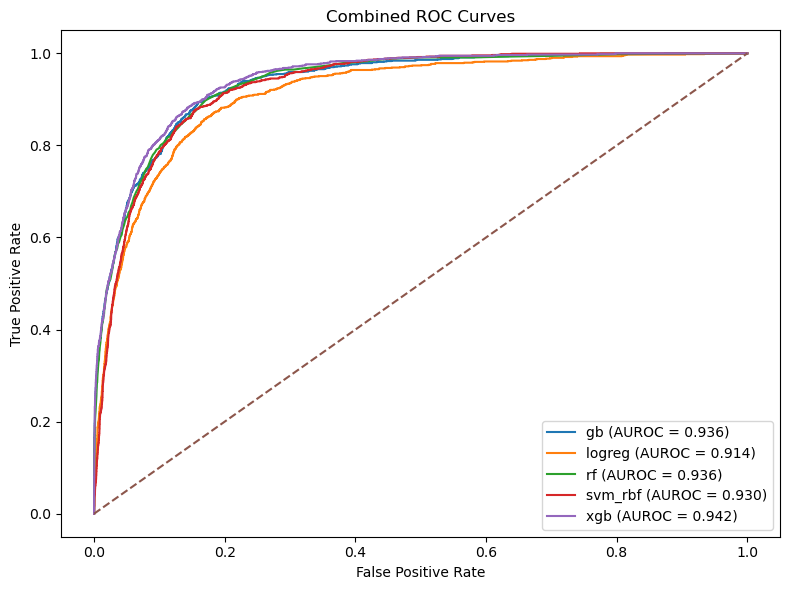

Saved combined ROC curve
ROC plotted for: ['gb', 'logreg', 'rf', 'svm_rbf', 'xgb']


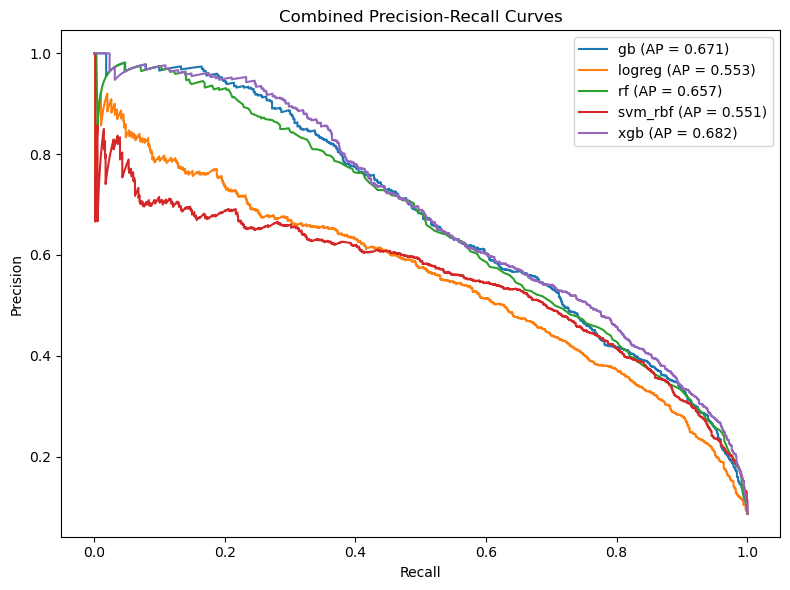

Saved combined PR curve
PR plotted for: ['gb', 'logreg', 'rf', 'svm_rbf', 'xgb']


In [19]:
# concate and summarize the baseline results

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


# Set baseline directory
baseline_dir = CFG.outputs_dir / "baseline"
# print("Reading from:", baseline_dir)


# Collect each model folder
model_dirs = [d for d in baseline_dir.iterdir() if d.is_dir()]
model_dirs = sorted(model_dirs, key=lambda x: x.name)

if not model_dirs:
    raise ValueError(f"No model folders found under: {baseline_dir}")

print("model folders:", [d.name for d in model_dirs])


# Read metrics into one table
rows = []

for model_dir in model_dirs:
    model_name = model_dir.name
    metrics_path = model_dir / f"{model_name}_metrics.json"
    
    if not metrics_path.exists():
        print(f"Skip {model_name}: metrics file not found")
        continue
    
    with open(metrics_path, "r") as f:
        metrics = json.load(f)
    
    row = {"model": model_name}
    row.update(metrics)
    rows.append(row)

results_df = pd.DataFrame(rows)

preferred_cols = [
    "model", "accuracy", "precision", "recall", "f1", "auroc", "ap", "threshold"
]
results_df = results_df[[c for c in preferred_cols if c in results_df.columns]]

# Sort by AUROC then AP if available
sort_cols = [c for c in ["auroc", "ap"] if c in results_df.columns]
if sort_cols:
    results_df = results_df.sort_values(sort_cols, ascending=False).reset_index(drop=True)

print("\nCombined metrics table:")
display(results_df)

# Save combined table
results_csv_path = baseline_dir / "baseline_model_summary.csv"
results_md_path = baseline_dir / "baseline_model_summary.md"

results_df.to_csv(results_csv_path, index=False)
results_df.to_markdown(results_md_path, index=False)

# print("Saved metrics table to:", results_csv_path)
# print("Saved markdown table to:", results_md_path)
print("Saved metrics table")
print("Saved markdown table")

# plot combined ROC curves
plt.figure(figsize=(8, 6))

roc_models_plotted = []

for model_dir in model_dirs:
    model_name = model_dir.name
    pred_path = model_dir / f"{model_name}_test_predictions.csv"
    
    if not pred_path.exists():
        print(f"Skip ROC for {model_name}: prediction file not found")
        continue
    
    pred_df = pd.read_csv(pred_path)
    
    if not {"y_true", "y_prob"}.issubset(pred_df.columns):
        print(f"Skip ROC for {model_name}: required columns missing")
        continue
    
    y_true = pred_df["y_true"].to_numpy()
    y_prob = pred_df["y_prob"].to_numpy()
    
    if len(np.unique(y_true)) < 2:
        print(f"Skip ROC for {model_name}: only one class present in y_true")
        continue
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUROC = {roc_auc:.3f})")
    roc_models_plotted.append(model_name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curves")
plt.legend()
plt.tight_layout()

roc_fig_path = baseline_dir / "baseline_combined_roc_curve.png"
plt.savefig(roc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# print("Saved combined ROC curve to:", roc_fig_path)
print("Saved combined ROC curve")
print("ROC plotted for:", roc_models_plotted)

# -----------------------------
# 5. Plot combined PR curves
# -----------------------------
plt.figure(figsize=(8, 6))

pr_models_plotted = []

for model_dir in model_dirs:
    model_name = model_dir.name
    pred_path = model_dir / f"{model_name}_test_predictions.csv"
    
    if not pred_path.exists():
        print(f"Skip PR for {model_name}: prediction file not found")
        continue
    
    pred_df = pd.read_csv(pred_path)
    
    if not {"y_true", "y_prob"}.issubset(pred_df.columns):
        print(f"Skip PR for {model_name}: required columns missing")
        continue
    
    y_true = pred_df["y_true"].to_numpy()
    y_prob = pred_df["y_prob"].to_numpy()
    
    if len(np.unique(y_true)) < 2:
        print(f"Skip PR for {model_name}: only one class present in y_true")
        continue
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    
    plt.plot(recall, precision, label=f"{model_name} (AP = {ap:.3f})")
    pr_models_plotted.append(model_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Combined Precision-Recall Curves")
plt.legend()
plt.tight_layout()

pr_fig_path = baseline_dir / "baseline_combined_pr_curve.png"
plt.savefig(pr_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# print("Saved combined PR curve to:", pr_fig_path)
print("Saved combined PR curve")
print("PR plotted for:", pr_models_plotted)

In [23]:
# feature selection using L1-regularized 



L1_DIR = CFG.outputs_dir / "l1_selected"
L1_DIR.mkdir(parents=True, exist_ok=True)

# print("L1 outputs will be saved to:", L1_DIR)

In [26]:
import time
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
# Prepare raw features, also collapse selected categorical values such as race
X_train_raw = collapse_selected_categories(
    train_df.drop(columns=[y_col], errors="ignore")
).copy()

X_test_raw = collapse_selected_categories(
    test_df.drop(columns=[y_col], errors="ignore")
).copy()

y_train = train_df[y_col].to_numpy().astype(int)
y_test  = test_df[y_col].to_numpy().astype(int)

# Infer numeric / categorical columns
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]

# Build preprocessor
preprocessor_l1 = make_preprocessor(num_cols, cat_cols)

# Preprocess train/test
prep_start = time.perf_counter()
X_train_prepared = preprocessor_l1.fit_transform(X_train_raw)
X_test_prepared = preprocessor_l1.transform(X_test_raw)
prep_end = time.perf_counter()

feature_names_after_prep = preprocessor_l1.get_feature_names_out()

# print(f"Raw feature count before one-hot encoding: {X_train_raw.shape[1]}")
# print(f"Feature count after preprocessing / one-hot encoding: {X_train_prepared.shape[1]}")
# print(f"Preprocessing time: {prep_end - prep_start:.3f} seconds")

# L1-regularized logistic regression for embedded feature selection
# If too many / too few features are selected, adjust C
l1_selector = LogisticRegression(
    penalty="l1",
    C=0.05,
    solver="saga",
    class_weight="balanced",
    max_iter=5000,
    random_state=seed
)

sel_start = time.perf_counter()
l1_selector.fit(X_train_prepared, y_train)
sel_end = time.perf_counter()

coef_abs = np.abs(l1_selector.coef_.ravel())
selected_mask = coef_abs > 1e-8
selected_features = feature_names_after_prep[selected_mask]

print(f"L1 selection fitting time: {sel_end - sel_start:.3f} seconds")
print(f"Selected feature count after L1 selection: {selected_mask.sum()}")
print(f"Removed feature count after L1 selection: {(~selected_mask).sum()}")

if selected_mask.sum() == 0:
    raise ValueError("No feature was selected by L1. Try increasing C, e.g., C=0.1 or C=0.5.")

# Build selected train/test matrices for downstream models
X_train_l1_selected = pd.DataFrame(
    X_train_prepared[:, selected_mask],
    columns=selected_features,
    index=X_train_raw.index
)

X_test_l1_selected = pd.DataFrame(
    X_test_prepared[:, selected_mask],
    columns=selected_features,
    index=X_test_raw.index
)

print("Selected feature names:")
print(selected_features)

# Save selection details
l1_feature_table = pd.DataFrame({
    "feature": feature_names_after_prep,
    "coef": l1_selector.coef_.ravel(),
    "abs_coef": coef_abs,
    "selected": selected_mask,
}).sort_values("abs_coef", ascending=False)

display(l1_feature_table.head(50))

l1_feature_table.to_csv(L1_DIR / "l1_feature_selection_details.csv", index=False)
pd.DataFrame({"selected_feature": selected_features}).to_csv(
    L1_DIR / "l1_selected_features.csv", index=False
)

print("Saved:")
# print(L1_DIR / "l1_feature_selection_details.csv")
# print(L1_DIR / "l1_selected_features.csv")
print("L1 feature selection finished.")

L1 selection fitting time: 15.178 seconds
Selected feature count after L1 selection: 65
Removed feature count after L1 selection: 59
Selected feature names:
['los' 'age' 'sofa2_cardiovascular_24h_max' 'sofa2_coagulation_24h_max'
 'sofa2_liver_24h_max' 'sofa2_renal_24h_max' 'sofa2_cns_24h_max'
 'heart_rate_min' 'heart_rate_max' 'heart_rate_mean' 'sbp_min' 'sbp_max'
 'sbp_mean' 'dbp_min' 'dbp_max' 'dbp_mean' 'mbp_min' 'mbp_max' 'mbp_mean'
 'resp_rate_min' 'resp_rate_max' 'resp_rate_mean' 'temperature_min'
 'temperature_max' 'temperature_mean' 'spo2_min' 'spo2_max' 'spo2_mean'
 'glucose_min' 'glucose_max' 'gcs_min' 'gcs_motor' 'gcs_verbal' 'gcs_eyes'
 'gcs_unable' 'po2_min' 'po2_max'
 'first_careunit_Cardiac Vascular Intensive Care Unit (CVICU)'
 'first_careunit_Coronary Care Unit (CCU)'
 'first_careunit_Medical Intensive Care Unit (MICU)'
 'first_careunit_Neuro Intermediate' 'first_careunit_Neuro Stepdown'
 'first_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU)'
 'first_careunit

,feature,coef,abs_coef,selected
55,last_careunit_Cardiac Vascular Intensive Care ...,-0.836271,0.836271,True
39,first_careunit_Cardiac Vascular Intensive Care...,-0.836271,0.836271,True
62,last_careunit_Neuro Intermediate,-0.675233,0.675233,True
46,first_careunit_Neuro Intermediate,-0.675233,0.675233,True
64,last_careunit_Neuro Surgical Intensive Care Un...,0.616796,0.616796,True
48,first_careunit_Neuro Surgical Intensive Care U...,0.616796,0.616796,True
116,race_UNKNOWN,0.567402,0.567402,True
1,age,0.496303,0.496303,True
10,heart_rate_mean,0.491963,0.491963,True
115,race_UNABLE TO OBTAIN,0.456664,0.456664,True


Saved:
L1 feature selection finished.


[logreg_l1] Feature count after L1 selection: 65
[logreg_l1] Sub-train fitting time: 0.789 seconds
[logreg_l1] Validation prediction time: 0.007 seconds
[logreg_l1] Selected threshold from validation set: 0.7767
[logreg_l1] Final training time on full training set: 0.578 seconds
[logreg_l1] Test prediction time: 0.002 seconds
logreg_l1 {'accuracy': 0.9134924277191372, 'precision': 0.5010814708002884, 'recall': 0.6128747795414462, 'f1': 0.5513685045616818, 'auroc': 0.9131885913990884, 'ap': 0.5513664437835079, 'threshold': 0.7766521282815243}


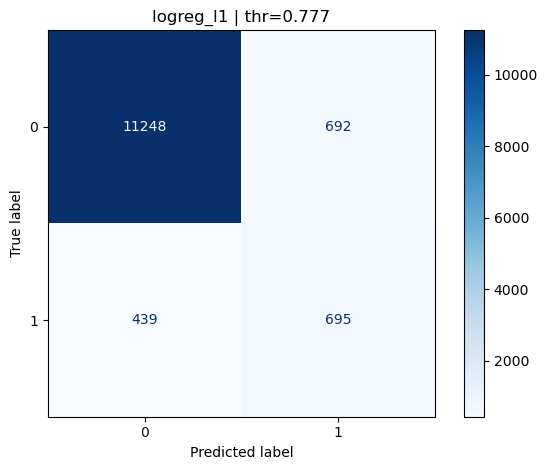

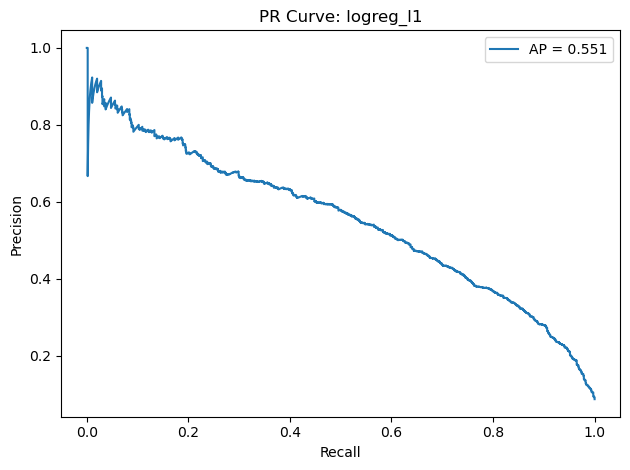

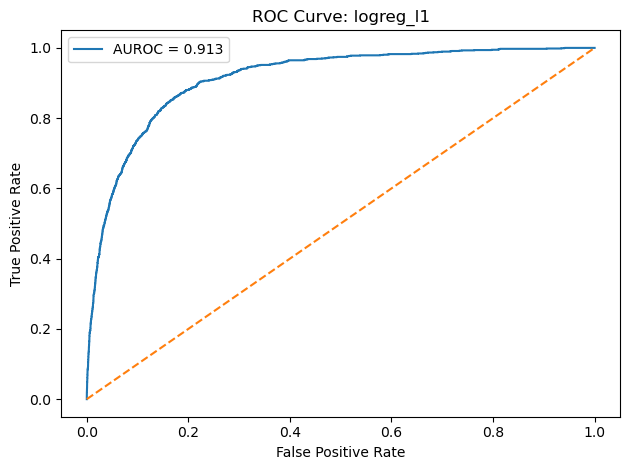

Finished Saving
[logreg_l1] Artifact saving time: 0.517 seconds
[logreg_l1] Done.


In [29]:
# after l1 feature selection logreg

import time
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

MODEL_NAME = "logreg_l1"

X_train_model = X_train_l1_selected.copy()
X_test_model  = X_test_l1_selected.copy()

sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_model.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_model.iloc[val_idx], y_train[val_idx]

print(f"[{MODEL_NAME}] Feature count after L1 selection: {X_train_model.shape[1]}")

clf = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=2000,
    solver="lbfgs",
    random_state=seed
)

train_start = time.perf_counter()
clf.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

val_pred_start = time.perf_counter()
y_val_prob = clf.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

clf_final = clone(clf)

final_train_start = time.perf_counter()
clf_final.fit(X_train_model, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

test_pred_start = time.perf_counter()
y_test_prob = clf_final.predict_proba(X_test_model)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, clf_final, y_test, y_test_prob, thr, mets, parent_dir=L1_DIR)
save_end = time.perf_counter()

print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

[rf_l1] Feature count after L1 selection: 65
[rf_l1] Sub-train fitting time: 3.111 seconds
[rf_l1] Validation prediction time: 0.054 seconds
[rf_l1] Selected threshold from validation set: 0.2300
[rf_l1] Final training time on full training set: 3.894 seconds
[rf_l1] Test prediction time: 0.067 seconds
rf_l1 {'accuracy': 0.9222885115496405, 'precision': 0.5442942942942943, 'recall': 0.6393298059964727, 'f1': 0.5879967558799676, 'auroc': 0.9360395820962544, 'ap': 0.6557560070245224, 'threshold': 0.23}


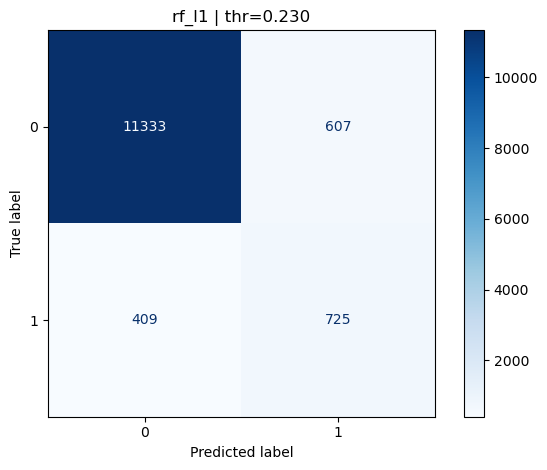

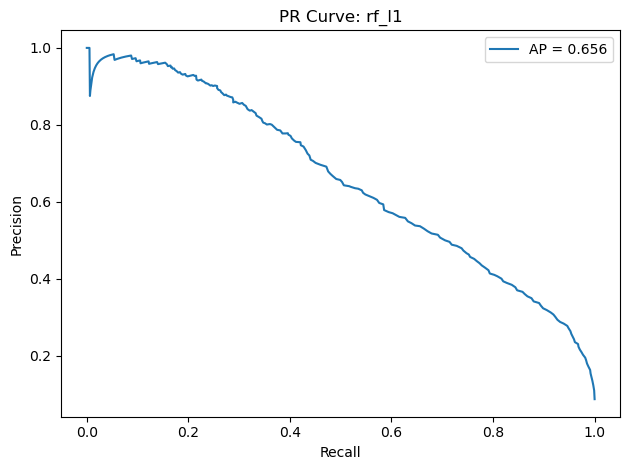

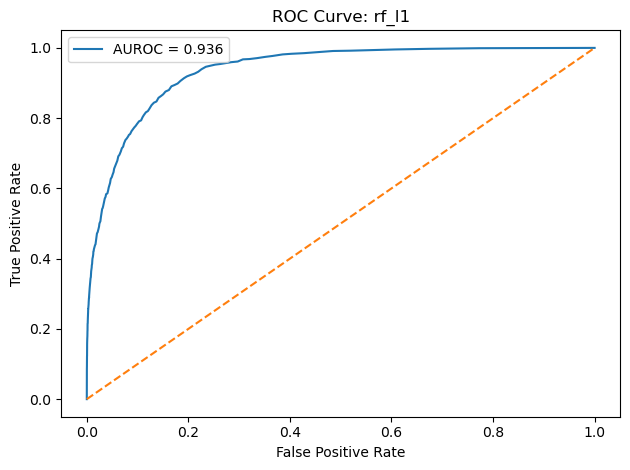

Finished Saving
[rf_l1] Artifact saving time: 0.588 seconds
[rf_l1] Done.


In [30]:
import time
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

MODEL_NAME = "rf_l1"

X_train_model = X_train_l1_selected.copy()
X_test_model  = X_test_l1_selected.copy()

sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_model.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_model.iloc[val_idx], y_train[val_idx]

print(f"[{MODEL_NAME}] Feature count after L1 selection: {X_train_model.shape[1]}")

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=seed,
    n_jobs=-1
)

train_start = time.perf_counter()
clf.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

val_pred_start = time.perf_counter()
y_val_prob = clf.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

clf_final = clone(clf)

final_train_start = time.perf_counter()
clf_final.fit(X_train_model, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

test_pred_start = time.perf_counter()
y_test_prob = clf_final.predict_proba(X_test_model)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, clf_final, y_test, y_test_prob, thr, mets, parent_dir=L1_DIR)
save_end = time.perf_counter()

print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

[gb_l1] Feature count after L1 selection: 65
[gb_l1] Sub-train fitting time: 33.910 seconds
[gb_l1] Validation prediction time: 0.019 seconds
[gb_l1] Selected threshold from validation set: 0.2777
[gb_l1] Final training time on full training set: 42.291 seconds
[gb_l1] Test prediction time: 0.024 seconds
gb_l1 {'accuracy': 0.9318494722349702, 'precision': 0.6142991533396049, 'recall': 0.5758377425044092, 'f1': 0.594446973145198, 'auroc': 0.9355557918930336, 'ap': 0.6700760195373665, 'threshold': 0.2777190795148197}


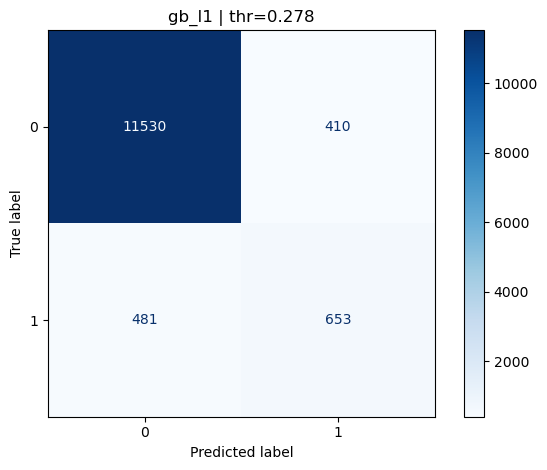

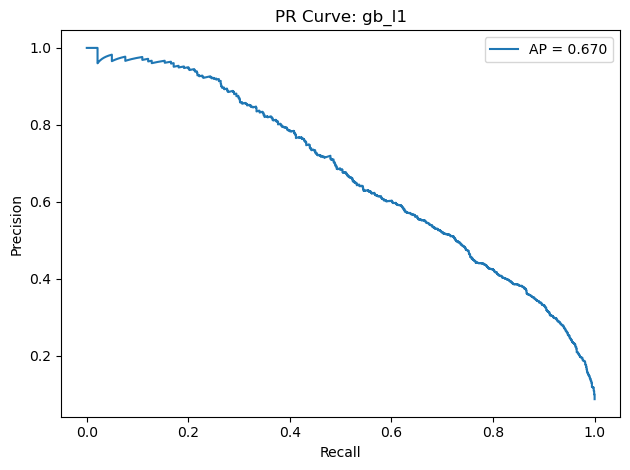

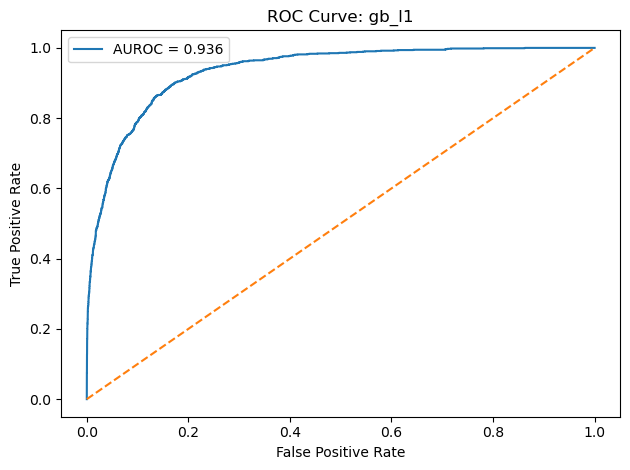

Finished Saving
[gb_l1] Artifact saving time: 0.435 seconds
[gb_l1] Done.


In [31]:
import time
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier

MODEL_NAME = "gb_l1"

X_train_model = X_train_l1_selected.copy()
X_test_model  = X_test_l1_selected.copy()

sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_model.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_model.iloc[val_idx], y_train[val_idx]

print(f"[{MODEL_NAME}] Feature count after L1 selection: {X_train_model.shape[1]}")

clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=seed
)

train_start = time.perf_counter()
clf.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

val_pred_start = time.perf_counter()
y_val_prob = clf.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

clf_final = clone(clf)

final_train_start = time.perf_counter()
clf_final.fit(X_train_model, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

test_pred_start = time.perf_counter()
y_test_prob = clf_final.predict_proba(X_test_model)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, clf_final, y_test, y_test_prob, thr, mets, parent_dir=L1_DIR)
save_end = time.perf_counter()

print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

[xgb_l1] Feature count after L1 selection: 65
[xgb_l1] Sub-train fitting time: 0.736 seconds
[xgb_l1] Validation prediction time: 0.007 seconds
[xgb_l1] Selected threshold from validation set: 0.7980
[xgb_l1] Final training time on full training set: 0.738 seconds
[xgb_l1] Test prediction time: 0.008 seconds
xgb_l1 {'accuracy': 0.930625669267248, 'precision': 0.6001765225066196, 'recall': 0.599647266313933, 'f1': 0.599911777679753, 'auroc': 0.9410324698152728, 'ap': 0.6813865071163876, 'threshold': 0.7980271577835083}


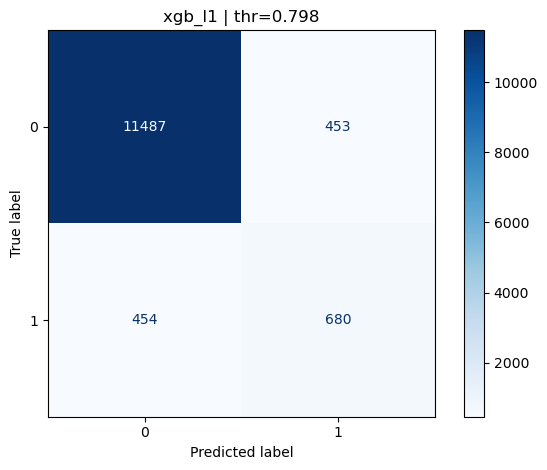

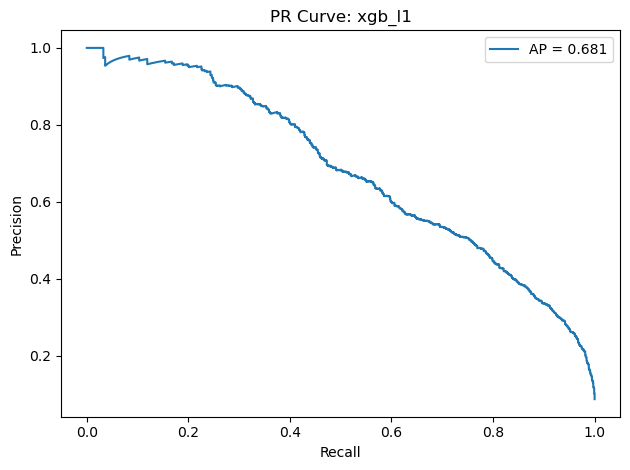

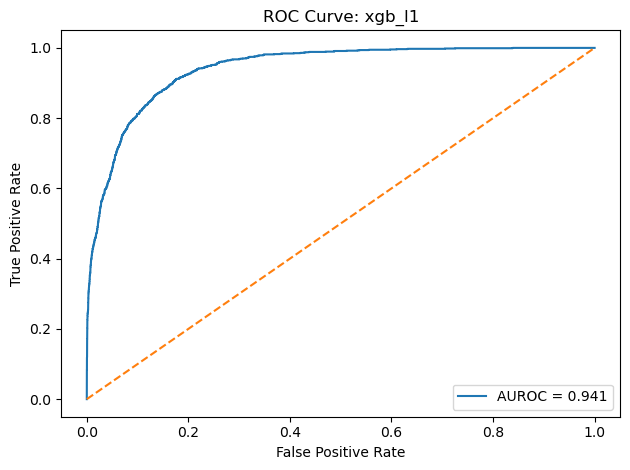

Finished Saving
[xgb_l1] Artifact saving time: 0.429 seconds
[xgb_l1] Done.


In [32]:
import time
from sklearn.base import clone
from xgboost import XGBClassifier

MODEL_NAME = "xgb_l1"

X_train_model = X_train_l1_selected.copy()
X_test_model  = X_test_l1_selected.copy()

sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_model.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_model.iloc[val_idx], y_train[val_idx]

print(f"[{MODEL_NAME}] Feature count after L1 selection: {X_train_model.shape[1]}")

n_neg = int((y_sub == 0).sum())
n_pos = int((y_sub == 1).sum())
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=seed,
    n_jobs=-1
)

train_start = time.perf_counter()
clf.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

val_pred_start = time.perf_counter()
y_val_prob = clf.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

clf_final = clone(clf)

n_neg_full = int((y_train == 0).sum())
n_pos_full = int((y_train == 1).sum())
clf_final.set_params(scale_pos_weight=(n_neg_full / n_pos_full if n_pos_full > 0 else 1.0))

final_train_start = time.perf_counter()
clf_final.fit(X_train_model, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

test_pred_start = time.perf_counter()
y_test_prob = clf_final.predict_proba(X_test_model)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, clf_final, y_test, y_test_prob, thr, mets, parent_dir=L1_DIR)
save_end = time.perf_counter()

print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

[svm_l1] Feature count after L1 selection: 65
[svm_l1] Sub-train fitting time: 527.480 seconds
[svm_l1] Validation prediction time: 12.424 seconds
[svm_l1] Selected threshold from validation set: 0.3130
[svm_l1] Final training time on full training set: 1008.651 seconds
[svm_l1] Test prediction time: 19.145 seconds
svm_l1 {'accuracy': 0.9203763194125746, 'precision': 0.5350414468726451, 'recall': 0.6261022927689595, 'f1': 0.5770012190166599, 'auroc': 0.9300587298633083, 'ap': 0.5548067147713527, 'threshold': 0.3130035950064954}


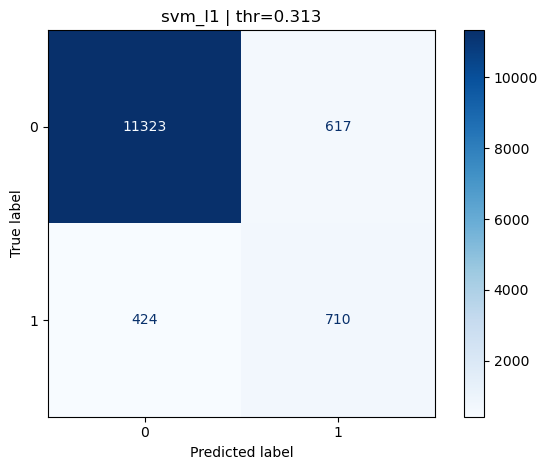

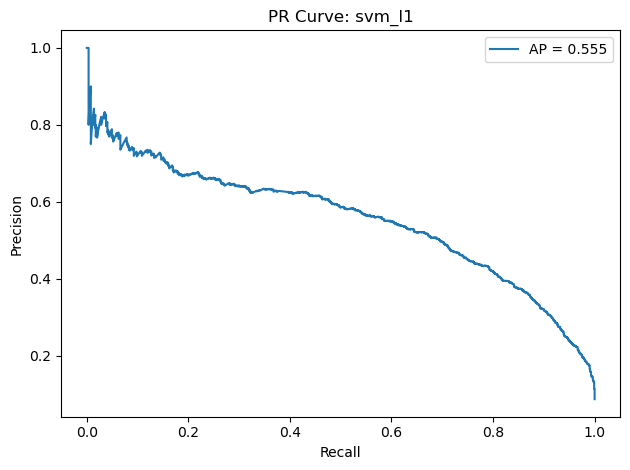

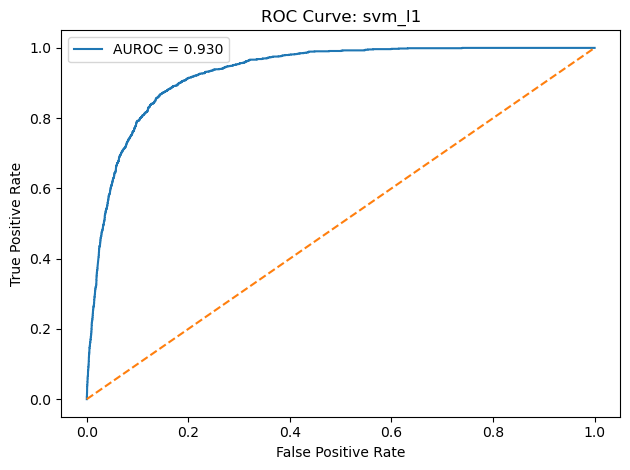

Finished Saving
[svm_l1] Artifact saving time: 0.448 seconds
[svm_l1] Done.


In [33]:
import time
from sklearn.base import clone
from sklearn.svm import SVC

MODEL_NAME = "svm_l1"

X_train_model = X_train_l1_selected.copy()
X_test_model  = X_test_l1_selected.copy()

sub_idx, val_idx = stratified_subsplit(y_train, val_size=CFG.val_size, seed=seed)
X_sub, y_sub = X_train_model.iloc[sub_idx], y_train[sub_idx]
X_val, y_val = X_train_model.iloc[val_idx], y_train[val_idx]

print(f"[{MODEL_NAME}] Feature count after L1 selection: {X_train_model.shape[1]}")

clf = SVC(
    C=1.0,
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=seed
)

train_start = time.perf_counter()
clf.fit(X_sub, y_sub)
train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Sub-train fitting time: {train_end - train_start:.3f} seconds")

val_pred_start = time.perf_counter()
y_val_prob = clf.predict_proba(X_val)[:, 1]
val_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Validation prediction time: {val_pred_end - val_pred_start:.3f} seconds")

thr = choose_threshold_by_f1_prcurve(y_val, y_val_prob)
print(f"[{MODEL_NAME}] Selected threshold from validation set: {thr:.4f}")

clf_final = clone(clf)

final_train_start = time.perf_counter()
clf_final.fit(X_train_model, y_train)
final_train_end = time.perf_counter()
print(f"[{MODEL_NAME}] Final training time on full training set: {final_train_end - final_train_start:.3f} seconds")

test_pred_start = time.perf_counter()
y_test_prob = clf_final.predict_proba(X_test_model)[:, 1]
test_pred_end = time.perf_counter()
print(f"[{MODEL_NAME}] Test prediction time: {test_pred_end - test_pred_start:.3f} seconds")

mets = compute_metrics(y_test, y_test_prob, thr)
print(MODEL_NAME, mets)

save_start = time.perf_counter()
save_artifacts(MODEL_NAME, clf_final, y_test, y_test_prob, thr, mets, parent_dir=L1_DIR)
save_end = time.perf_counter()

print(f"[{MODEL_NAME}] Artifact saving time: {save_end - save_start:.3f} seconds")
print(f"[{MODEL_NAME}] Done.")

model folders: ['gb_l1', 'logreg_l1', 'rf_l1', 'svm_l1', 'xgb_l1']

Combined metrics table:


,model,accuracy,precision,recall,f1,auroc,ap,threshold
0,xgb_l1,0.930626,0.600177,0.599647,0.599912,0.941032,0.681387,0.798027
1,rf_l1,0.922289,0.544294,0.639330,0.587997,0.936040,0.655756,0.230000
2,gb_l1,0.931849,0.614299,0.575838,0.594447,0.935556,0.670076,0.277719
3,svm_l1,0.920376,0.535041,0.626102,0.577001,0.930059,0.554807,0.313004
4,logreg_l1,0.913492,0.501081,0.612875,0.551369,0.913189,0.551366,0.776652


Saved metrics table
Saved markdown table


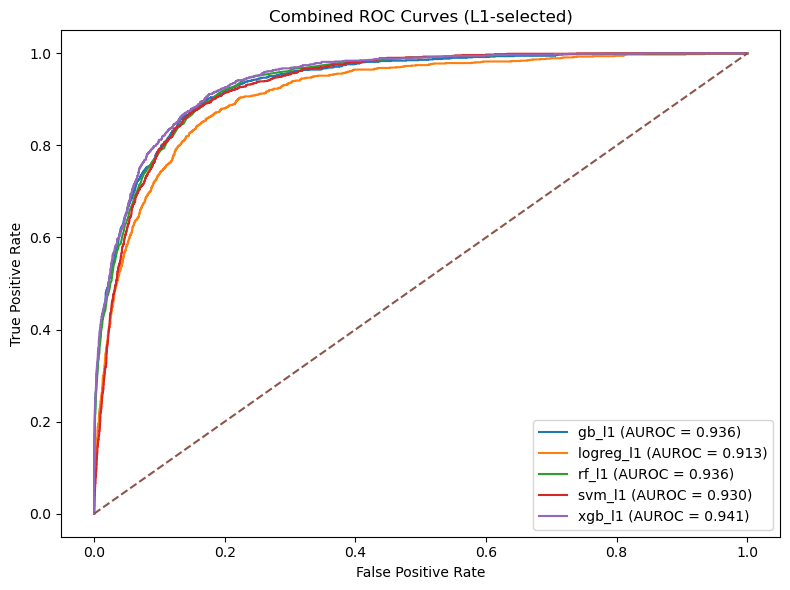

Saved combined ROC curve
ROC plotted for: ['gb_l1', 'logreg_l1', 'rf_l1', 'svm_l1', 'xgb_l1']


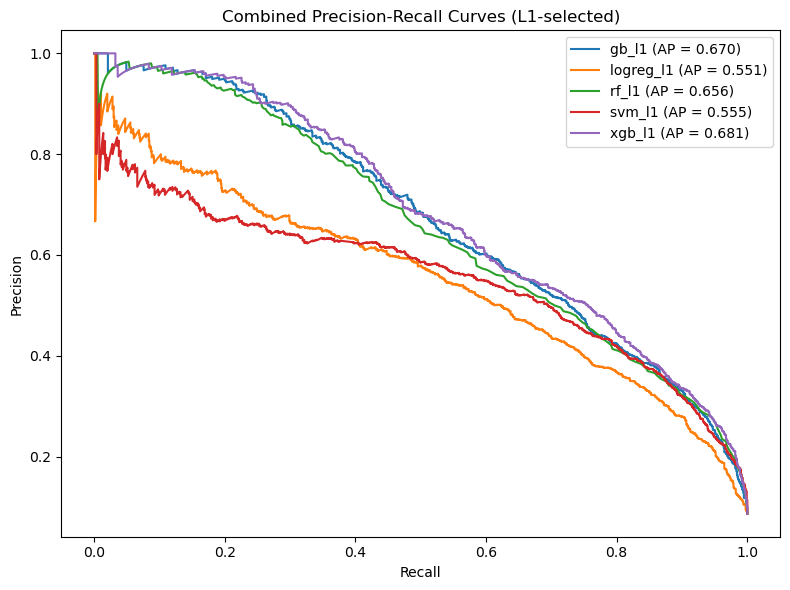

Saved combined PR curve
PR plotted for: ['gb_l1', 'logreg_l1', 'rf_l1', 'svm_l1', 'xgb_l1']


In [34]:
# concate and summarize the l1_selected results

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


# Set l1_selected directory
l1_dir = CFG.outputs_dir / "l1_selected"
# print("Reading from:", l1_dir)


# Collect each model folder
model_dirs = [d for d in l1_dir.iterdir() if d.is_dir()]
model_dirs = sorted(model_dirs, key=lambda x: x.name)

if not model_dirs:
    raise ValueError(f"No model folders found under: {l1_dir}")

print("model folders:", [d.name for d in model_dirs])


# Read metrics into one table
rows = []

for model_dir in model_dirs:
    model_name = model_dir.name
    metrics_path = model_dir / f"{model_name}_metrics.json"
    
    if not metrics_path.exists():
        print(f"Skip {model_name}: metrics file not found")
        continue
    
    with open(metrics_path, "r") as f:
        metrics = json.load(f)
    
    row = {"model": model_name}
    row.update(metrics)
    rows.append(row)

results_df = pd.DataFrame(rows)

preferred_cols = [
    "model", "accuracy", "precision", "recall", "f1", "auroc", "ap", "threshold"
]
results_df = results_df[[c for c in preferred_cols if c in results_df.columns]]

# Sort by AUROC then AP if available
sort_cols = [c for c in ["auroc", "ap"] if c in results_df.columns]
if sort_cols:
    results_df = results_df.sort_values(sort_cols, ascending=False).reset_index(drop=True)

print("\nCombined metrics table:")
display(results_df)

# Save combined table
results_csv_path = l1_dir / "l1_model_summary.csv"
results_md_path = l1_dir / "l1_model_summary.md"

results_df.to_csv(results_csv_path, index=False)
results_df.to_markdown(results_md_path, index=False)

print("Saved metrics table")
print("Saved markdown table")


# plot combined ROC curves
plt.figure(figsize=(8, 6))

roc_models_plotted = []

for model_dir in model_dirs:
    model_name = model_dir.name
    pred_path = model_dir / f"{model_name}_test_predictions.csv"
    
    if not pred_path.exists():
        print(f"Skip ROC for {model_name}: prediction file not found")
        continue
    
    pred_df = pd.read_csv(pred_path)
    
    if not {"y_true", "y_prob"}.issubset(pred_df.columns):
        print(f"Skip ROC for {model_name}: required columns missing")
        continue
    
    y_true = pred_df["y_true"].to_numpy()
    y_prob = pred_df["y_prob"].to_numpy()
    
    if len(np.unique(y_true)) < 2:
        print(f"Skip ROC for {model_name}: only one class present in y_true")
        continue
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUROC = {roc_auc:.3f})")
    roc_models_plotted.append(model_name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curves (L1-selected)")
plt.legend()
plt.tight_layout()

roc_fig_path = l1_dir / "l1_combined_roc_curve.png"
plt.savefig(roc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved combined ROC curve")
print("ROC plotted for:", roc_models_plotted)


# Plot combined PR curves
plt.figure(figsize=(8, 6))

pr_models_plotted = []

for model_dir in model_dirs:
    model_name = model_dir.name
    pred_path = model_dir / f"{model_name}_test_predictions.csv"
    
    if not pred_path.exists():
        print(f"Skip PR for {model_name}: prediction file not found")
        continue
    
    pred_df = pd.read_csv(pred_path)
    
    if not {"y_true", "y_prob"}.issubset(pred_df.columns):
        print(f"Skip PR for {model_name}: required columns missing")
        continue
    
    y_true = pred_df["y_true"].to_numpy()
    y_prob = pred_df["y_prob"].to_numpy()
    
    if len(np.unique(y_true)) < 2:
        print(f"Skip PR for {model_name}: only one class present in y_true")
        continue
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    
    plt.plot(recall, precision, label=f"{model_name} (AP = {ap:.3f})")
    pr_models_plotted.append(model_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Combined Precision-Recall Curves (L1-selected)")
plt.legend()
plt.tight_layout()

pr_fig_path = l1_dir / "l1_combined_pr_curve.png"
plt.savefig(pr_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved combined PR curve")
print("PR plotted for:", pr_models_plotted)